# Chapter Three
# Numerical Methods for Boundary Value Problems

**Mesfin Mekuria Feb, 2026** 

 A variety of numerical methods have been developed to solve boundary value problems (BVPs) for ordinary differential equations problems in which solution conditions are specified at more than one point in the domain, typically at the endpoints of an interval. Among the most fundamental and widely used of these techniques are the Shooting Method and the Finite Difference Method (FDM). 
 
 In the following sections, we will explore both approaches in detail: the Shooting Method, which reformulates the BVP as an initial value problem and iteratively adjusts unknown initial conditions to satisfy the boundary constraints; and the Finite Difference Method, which discretizes the differential equation over a grid and replaces derivatives with algebraic approximations to yield a system of linear or nonlinear equations. 
 
 Each method offers distinct advantages and limitations, and understanding both provides a solid foundation for tackling a broad class of boundary value problems in scientific and engineering applications.

## 3.1. Shooting Method

The two-point boundary-value problems in this course involve a second-order differential equation of the form:

$$
y'' = f(x, y, y'), \quad a < x < b \tag{1}
$$

together with the boundary conditions

$$
y(a) = \alpha, \quad y(b) = \beta. \tag{2}
$$

#### 3.1.1. Linear Shooting Method

Consider the linear boundary-value problem
$$
y'' = p(x)\,y' + q(x)\,y + r(x), \qquad a < x < b, \tag{3}
$$
subject to the boundary conditions
$$
y(a) = \alpha, \qquad y(b) = \beta. \tag{4}
$$
Assume that:
1. The coefficient functions $p(x)$, $q(x)$, and $r(x)$ are continuous on the closed interval $[a, b]$;
2. The coefficient $q(x)$ is strictly positive on $[a, b]$, i.e., $q(x) > 0$ for all $x \in [a, b]$.
Then the boundary-value problem has a unique solution on $[a, b]$.

To solve a linear second-order boundary value problem of the form (3)--(4), we reformulate it as a combination of two initial value problems (IVPs):

$$
y_1'' = p(x) y_1' + q(x) y_1 + r(x), \quad a < x < b, \quad y_1(a) = \alpha, \quad y_1'(a) = 0, \tag{5}
$$

and

$$
y_2'' = p(x) y_2' + q(x) y_2, \quad a < x < b, \quad y_2(a) = 0, \quad y_2'(a) = 1. \tag{6}
$$

The existence and uniqueness of solutions to such IVPs were established in the previous chapter, provided $p$, $q$, and $r$ are continuous on $[a,b]$.

Let $y_1(x)$ and $y_2(x)$ denote the (unique) solutions to (5) and (6), respectively. Under the hypotheses of the Theorem, one can show that $y_2(b) \ne 0$; indeed, the case $y_2(b) = 0$ would contradict the uniqueness of the boundary-value problem (see the Exercise).

Define the function

$$
y(x) = y_1(x) + \frac{\beta - y_1(b)}{y_2(b)}\, y_2(x).    \tag{7}
$$

We claim that $y(x)$ solves the original boundary-value problem (3)--(4).

**Verification.** First, differentiate (7):

$$
y'(x) = y_1'(x) + \frac{\beta - y_1(b)}{y_2(b)}\, y_2'(x), \qquad
y''(x) = y_1''(x) + \frac{\beta - y_1(b)}{y_2(b)}\, y_2''(x).
$$

Substituting the differential equations for $y_1''$ and $y_2''$:

$$
\begin{align}
y''(x) &= \bigl[p(x) y_1' + q(x) y_1 + r(x)\bigr] 
        + \frac{\beta - y_1(b)}{y_2(b)} \bigl[p(x) y_2' + q(x) y_2\bigr] \\
       &= p(x) \left( y_1' + \frac{\beta - y_1(b)}{y_2(b)} y_2' \right)
        + q(x) \left( y_1 + \frac{\beta - y_1(b)}{y_2(b)} y_2 \right) + r(x) \\
       &= p(x) y'(x) + q(x) y(x) + r(x).
\end{align}
$$

Thus, $y(x)$ satisfies the differential equation (3).

Next, check the boundary conditions:

$$
y(a) = y_1(a) + \frac{\beta - y_1(b)}{y_2(b)}\, y_2(a) = \alpha + \frac{\beta - y_1(b)}{y_2(b)} \cdot 0 = \alpha,
$$

$$
y(b) = y_1(b) + \frac{\beta - y_1(b)}{y_2(b)}\, y_2(b) = y_1(b) + \bigl(\beta - y_1(b)\bigr) = \beta.
$$

Hence, both boundary conditions (4) are satisfied.

Therefore, the solution to the linear BVP is expressed as a linear combination of the solutions to two IVPs. In practice, the *linear shooting method* proceeds by numerically solving the IVPs (5) and (6) (e.g., using Runge–Kutta methods), and then constructing the approximate BVP solution via (7).

- Graphically, the method is illustrated in the figure below.
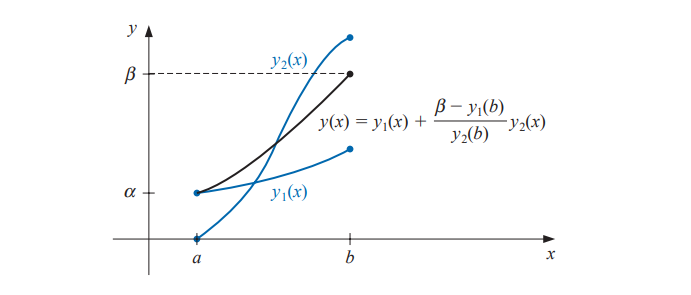


*Figure: Graphical representation of the linear shooting method.*

- This "shooting" hits the target after one trial because the problem is linear. For nonlinear problems (next section), multiple iterations are required.

- We use the fourth-order Runge-Kutta method to approximate $y_1(x)$ and $y_2(x)$, though other IVP solvers are also applicable.


##### Procedures for the Linear Shooting Method

To approximate the solution of the boundary value problem:

$$
y'' = p(x) y' + q(x) y + r(x), \quad a < x < b,
$$
with boundary conditions

$$
y(a) = \alpha, \quad y(b) = \beta,
$$
we proceed as follows:

##### Step 1: Convert to Two IVPs

Solve the following two second-order IVPs:

$$
\begin{cases}
y_1'' = p(x) y_1' + q(x) y_1 + r(x), \\
y_1(a) = \alpha, \quad y_1'(a) = 0,
\end{cases} \tag{8}
$$

$$
\begin{cases}
y_2'' = p(x) y_2' + q(x) y_2, \\
y_2(a) = 0, \quad y_2'(a) = 1.
\end{cases} \tag{9}
$$

##### Step 2: Reduce to First-Order Systems

Let $ u_1 = y_1 $, $ u_2 = y_1' $, $ v_1 = y_2 $, $ v_2 = y_2' $. Then:

**For $ u_1, u_2 $:**

$$
\begin{cases}
u_1' = u_2, & u_1(a) = \alpha, \\
u_2' = p(x) u_2 + q(x) u_1 + r(x), & u_2(a) = 0.
\end{cases}
$$

**For $ v_1, v_2 $:**

$$
\begin{cases}
v_1' = v_2, & v_1(a) = 0, \\
v_2' = p(x) v_2 + q(x) v_1, & v_2(a) = 1.
\end{cases}
$$

##### Step 3: Apply Fourth-Order Runge-Kutta Method

For each system, use the classical RK4 method on a grid $ x_i = a + i h $, $ i = 0, 1, \dots, N $, $ h = (b-a)/N $.

**For the $ u $-system:**

$$
\begin{align*}
k_{1,1} &= h u_{2,i}, \\
k_{1,2} &= h \left[ p(x_i) u_{2,i} + q(x_i) u_{1,i} + r(x_i) \right], \\
k_{2,1} &= h \left( u_{2,i} + \tfrac{1}{2} k_{1,2} \right), \\
k_{2,2} &= h \left[ p(x_i + \tfrac{h}{2}) \left( u_{2,i} + \tfrac{1}{2} k_{1,2} \right) + q(x_i + \tfrac{h}{2}) \left( u_{1,i} + \tfrac{1}{2} k_{1,1} \right) + r(x_i + \tfrac{h}{2}) \right], \\
k_{3,1} &= h \left( u_{2,i} + \tfrac{1}{2} k_{2,2} \right), \\
k_{3,2} &= h \left[ p(x_i + \tfrac{h}{2}) \left( u_{2,i} + \tfrac{1}{2} k_{2,2} \right) + q(x_i + \tfrac{h}{2}) \left( u_{1,i} + \tfrac{1}{2} k_{2,1} \right) + r(x_i + \tfrac{h}{2}) \right], \\
k_{4,1} &= h \left( u_{2,i} + k_{3,2} \right), \\
k_{4,2} &= h \left[ p(x_i + h) \left( u_{2,i} + k_{3,2} \right) + q(x_i + h) \left( u_{1,i} + k_{3,1} \right) + r(x_i + h) \right], \\
u_{1,i+1} &= u_{1,i} + \tfrac{1}{6} (k_{1,1} + 2k_{2,1} + 2k_{3,1} + k_{4,1}), \\
u_{2,i+1} &= u_{2,i} + \tfrac{1}{6} (k_{1,2} + 2k_{2,2} + 2k_{3,2} + k_{4,2}).
\end{align*}
$$

**For the $ v $-system:**

$$
\begin{align*}
k'_{1,1} &= h v_{2,i}, \\
k'_{1,2} &= h \left[ p(x_i) v_{2,i} + q(x_i) v_{1,i} \right], \\
k'_{2,1} &= h \left( v_{2,i} + \tfrac{1}{2} k'_{1,2} \right), \\
k'_{2,2} &= h \left[ p(x_i + \tfrac{h}{2}) \left( v_{2,i} + \tfrac{1}{2} k'_{1,2} \right) + q(x_i + \tfrac{h}{2}) \left( v_{1,i} + \tfrac{1}{2} k'_{1,1} \right) \right], \\
k'_{3,1} &= h \left( v_{2,i} + \tfrac{1}{2} k'_{2,2} \right), \\
k'_{3,2} &= h \left[ p(x_i + \tfrac{h}{2}) \left( v_{2,i} + \tfrac{1}{2} k'_{2,2} \right) + q(x_i + \tfrac{h}{2}) \left( v_{1,i} + \tfrac{1}{2} k'_{2,1} \right) \right], \\
k'_{4,1} &= h \left( v_{2,i} + k'_{3,2} \right), \\
k'_{4,2} &= h \left[ p(x_i + h) \left( v_{2,i} + k'_{3,2} \right) + q(x_i + h) \left( v_{1,i} + k'_{3,1} \right) \right], \\
v_{1,i+1} &= v_{1,i} + \tfrac{1}{6} (k'_{1,1} + 2k'_{2,1} + 2k'_{3,1} + k'_{4,1}), \\
v_{2,i+1} &= v_{2,i} + \tfrac{1}{6} (k'_{1,2} + 2k'_{2,2} + 2k'_{3,2} + k'_{4,2}).
\end{align*}
$$

##### Step 4: Combine Solutions

The approximate solution to the BVP at each grid point $ x_i $ is:

$$
w_i = u_{1,i} + \frac{\beta - u_{1,N}}{v_{1,N}} v_{1,i}, \tag{10}
$$

where $ u_{1,N} \approx y_1(b) $, $ v_{1,N} \approx y_2(b) $.

This $ w_i \approx y(x_i) $ satisfies the boundary conditions and approximates the solution across $[a,b]$.

##### Example 1

Apply the Linear Shooting Method with $N = 10$ to the boundary-value problem

$$
y'' = -\frac{4}{x} y' - \frac{2}{x^2} y + \frac{2 \ln x}{x^2}, \quad 1 < x < 2, \tag{11}
$$

with boundary conditions

$$
y(1) = \frac{1}{2}, \quad y(2) = \ln 2. \tag{12}
$$

The exact solution is  $y(x)= 4/x - 2/x^2+log(x) - 1.5$

---

**Solution:**  First, transform the BVP into two second-order initial value problems (IVPs):

$$
y_1'' = -\frac{4}{x} y_1' - \frac{2}{x^2} y_1 + \frac{2 \ln x}{x^2}, \quad y_1(1) = \frac{1}{2}, \quad y_1'(1) = 0, \tag{13}
$$

$$
y_2'' = -\frac{4}{x} y_2' - \frac{2}{x^2} y_2, \quad y_2(1) = 0, \quad y_2'(1) = 1. \tag{14}
$$

-----
Next, reduce each second-order IVP to a system of first-order equations.

**For (13):** Let $w_1 = y_1$, $w_2 = y_1'$. Then:

$$
\begin{cases}
w_1' = w_2, & w_1(1) = \frac{1}{2}, \\[6pt]
w_2' = -\frac{4}{x} w_2 - \frac{2}{x^2} w_1 + \frac{2 \ln x}{x^2}, & w_2(1) = 0.
\end{cases} \tag{15}
$$

**For (14):** Let $u_1 = y_2$, $u_2 = y_2'$. Then:

$$
\begin{cases}
u_1' = u_2, & u_1(1) = 0, \\[6pt]
u_2' = -\frac{4}{x} u_2 - \frac{2}{x^2} u_1, & u_2(1) = 1.
\end{cases} \tag{16}
$$

---

We now apply the fourth-order Runge–Kutta method to both systems over $[1, 2]$ with $N = 10$, so $h = 0.1$.

Linear Shooting Method  (N = 10,  h = 0.10000)
z (shooting parameter)  = 1.0000391305

   x       y_numerical      y_exact         |error|
-------------------------------------------------------
1.0000     0.50000000     0.50000000     0.00e+00
1.1000     0.57876151     0.57878125     1.97e-05
1.2000     0.62674220     0.62676600     2.38e-05
1.3000     0.65583333     0.65585539     2.21e-05
1.4000     0.67318852     0.67320693     1.84e-05
1.5000     0.68322847     0.68324289     1.44e-05
1.6000     0.68874298     0.68875363     1.07e-05
1.7000     0.69152058     0.69152791     7.32e-06
1.8000     0.69272048     0.69272494     4.46e-06
1.9000     0.69309839     0.69310042     2.04e-06
2.0000     0.69314718     0.69314718     1.11e-16

Maximum absolute error = 2.38e-05



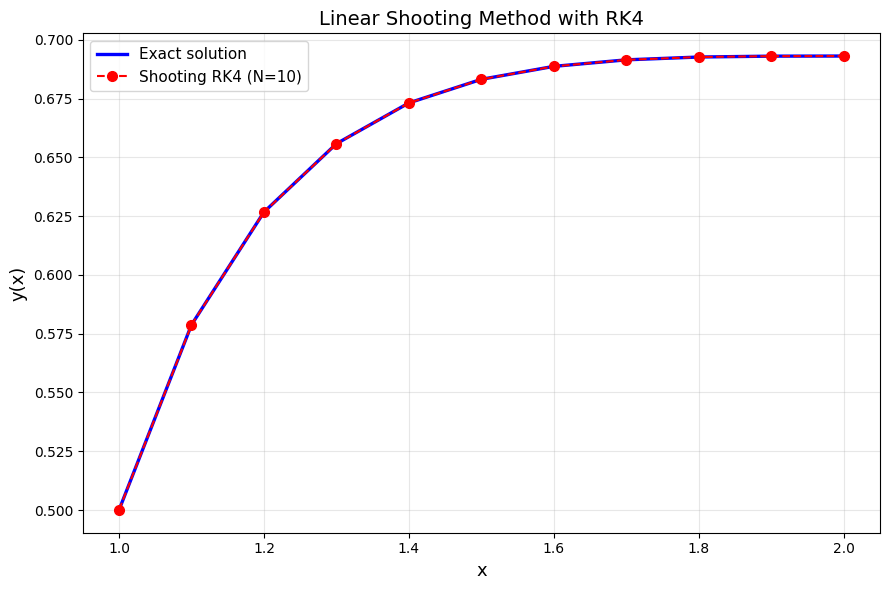

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────
# Problem definition
# ────────────────────────────────────────────────
def p(x): return -4 / x
def q(x): return -2 / x**2
def r(x): return 2 * np.log(x) / x**2

# Exact solution (verified)
def y_exact(x):
    return 4/x - 2/x**2 + np.log(x) - 1.5

# Domain and boundary conditions
a, b       = 1.0, 2.0
alpha      = 0.5          # y(a) = 1/2
beta       = np.log(2)    # y(b) = ln(2)
N          = 10           # number of intervals (try 10, 20, 40, 80...)
h          = (b - a) / N
x_grid     = np.linspace(a, b, N+1)

# ────────────────────────────────────────────────
# Right-hand side functions for the two IVPs
# ────────────────────────────────────────────────
def rhs_u(t, yvec):   # inhomogeneous (particular-like)
    y, yp = yvec
    return np.array([yp, p(t)*yp + q(t)*y + r(t)])

def rhs_v(t, yvec):   # homogeneous
    y, yp = yvec
    return np.array([yp, p(t)*yp + q(t)*y])

# ────────────────────────────────────────────────
#  RK4 Solver Implementation
# ────────────────────────────────────────────────
def solve_rk4_fixed_step(rhs, x_grid, y0):
    """
    Solves Y' = rhs(x, Y) using classic fixed-step RK4.
    """
    n_steps = len(x_grid)
    n_vars  = len(y0)
    Y_sol   = np.zeros((n_vars, n_steps))
    Y_sol[:, 0] = y0
    
    for i in range(n_steps - 1):
        x = x_grid[i]
        h_step = x_grid[i+1] - x_grid[i]
        Y_curr = Y_sol[:, i]
        
        k1 = rhs(x, Y_curr)
        k2 = rhs(x + h_step/2, Y_curr + h_step * k1 / 2)
        k3 = rhs(x + h_step/2, Y_curr + h_step * k2 / 2)
        k4 = rhs(x + h_step,   Y_curr + h_step * k3)
        
        Y_sol[:, i+1] = Y_curr + (h_step / 6) * (k1 + 2*k2 + 2*k3 + k4)
        
    return Y_sol

# ────────────────────────────────────────────────
# Solve two IVPs using Classical RK4
# ────────────────────────────────────────────────

# u-particular: y(a)=α, y'(a)=0
sol_u_array = solve_rk4_fixed_step(rhs_u, x_grid, [alpha, 0.0])
u = sol_u_array[0, :]          # u(x) values on grid

# v-homogeneous: y(a)=0, y'(a)=1
sol_v_array = solve_rk4_fixed_step(rhs_v, x_grid, [0.0, 1.0])
v = sol_v_array[0, :]          # v(x) values on grid

# ────────────────────────────────────────────────
# Shooting: find linear combination coefficient z
# ────────────────────────────────────────────────
z = (beta - u[-1]) / v[-1]
# Approximate solution
w = u + z * v
# Exact values + error
y_ex = y_exact(x_grid)
error = np.abs(y_ex - w)
max_error = error.max()

# ────────────────────────────────────────────────
# Output
# ────────────────────────────────────────────────

print(f"Linear Shooting Method  (N = {N},  h = {h:.5f})")
print(f"z (shooting parameter)  = {z:.10f}\n")

print("   x       y_numerical      y_exact         |error|")
print("-" * 55)

for xi, w_i, yex_i, err_i in zip(x_grid, w, y_ex, error):
    print(f"{xi:6.4f}   {w_i:12.8f}   {yex_i:12.8f}   {err_i:10.2e}")

print(f"\nMaximum absolute error = {max_error:.2e}\n")

# ────────────────────────────────────────────────
# Plot
# ────────────────────────────────────────────────

plt.figure(figsize=(9, 6))
plt.plot(x_grid, y_ex, 'b-', lw=2.4, label='Exact solution')
plt.plot(x_grid, w, 'ro--', lw=1.5, markersize=7, label=f'Shooting RK4 (N={N})')
plt.xlabel('x', fontsize=13)
plt.ylabel('y(x)', fontsize=13)
plt.title('Linear Shooting Method with RK4', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', fontsize=11)
plt.tight_layout()
plt.show()

The high accuracy is due to the fourth-order convergence ($O(h^4)$) of the Runge–Kutta method used to solve the IVPs.

#### Lab Practise Exercises

**Problem 1**: Solve the boundary value problem:

$$
y'' = y' + 2y + \cos x, \quad 0 < x < \frac{\pi}{2}, \quad y(0) = -0.3, \;\; y\!\left(\frac{\pi}{2}\right) = -0.1
$$
Exact solution:   $ y(x) = -\frac{1}{10}\big(\sin x + 3\cos x\big)$

**Problem 2**: Solve the boundary value problem:
$$
y'' = 2y' - y + x e^x - x, \quad 0 < x < 2, \quad y(0) = 0, \;\; y(2) = -4
$$
Exact solution: $
y(x) = \frac{1}{6}x^3 e^x - \frac{5}{3}x e^x + 2e^x - x - 2
$


**Tasks:**
- Implement the linear shooting method with classical RK4 ($O(h^4)$).
- Compute numerical solutions for $N = 10, 20, 40, 80$.
- Plot: (a) numerical vs. exact solution, (b) absolute error vs. $x$.
- Compute the maximum absolute error and observed convergence order.
- Does the error decrease as $O(h^4)$?

#### 3.1.2. Nonlinear Shooting Method

- The shooting technique for the nonlinear second-order boundary-value problem
  $$
  y''=f(x,y,y'),\;\;\; a<x<b,\;
  y(a)=\alpha, \;\; y(b)=\beta \tag{1}
  $$
  is similar to the linear technique, except that the solution to a nonlinear problem cannot be expressed as a linear combination of the solutions to two initial-value problems.

- Instead, we approximate the solution to the boundary-value problem by using the solutions to a sequence of initial-value problems involving a parameter $t$.

- These problems have the form
  $$
  y''=f(x,y,y'),\;\;\; a<x<b,\;
  y(a)=\alpha, \;\; y'(a)=t \tag{2}
  $$

- We do this by choosing the parameters $t = t_k$ in a manner to ensure that
  $$
  \lim_{k\rightarrow \infty}y(b,t_k)=y(b)=\beta \tag{3}
  $$
  where $y(x, t_k)$ denotes the solution to the initial-value problem (2) with $t = t_k$, and $y(x)$ denotes the solution to the boundary-value problem (1).

- Shooting methods for nonlinear problems require iterations to approach the "target".

- We start with a parameter $t_0$ that determines the initial elevation at which the object is fired from the point $(a, \alpha)$ and along the curve described by the solution to the initial-value problem:
  $$
  y''=f(x,y,y'),\;\;\; a<x<b,\;
  y(a)=\alpha, \;\; y'(a)=t_0
  $$


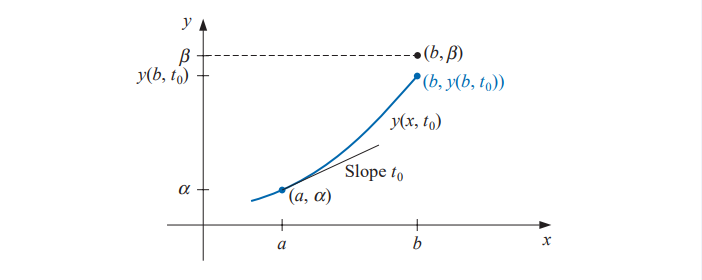  

  *Figure: The procedure of shooting to determine the initial elevation.*

---

- If $y(b, t_0)$ is not sufficiently close to $\beta$, we correct our approximation by choosing elevations $t_1, t_2$, and so on, until $y(b, t_k)$ is sufficiently close to "hitting" $\beta$.
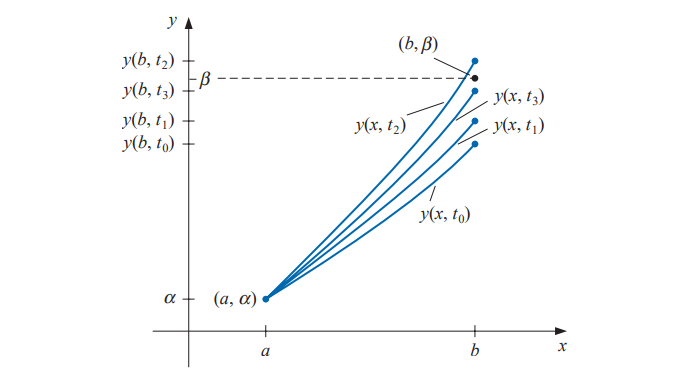

  *Figure: Shooting method for different level.*

---

- If $y(x, t)$ denotes the solution to the initial-value problem, we next determine $t$ with
  $$
  y(b,t)-\beta=0
  $$
  which is a nonlinear equation in the variable $t$.

- Problems of this type can be solved using **Secant method** or **Newton-Raphson methods**.

- To use the **Secant method** to solve the problem, we need to choose initial approximations $t_0$ and $t_1$, and then generate the remaining terms of the sequence by:
  $$
  t_k=t_{k-1}-\frac{(y(b,t_{k-1})-\beta)(t_{k-1}-t_{k-2})}{y(b,t_{k-1})-y(b,t_{k-2})}, \quad k=2,3,\dots
  $$

- To use the more powerful **Newton's method** to generate the sequence $\{t_k\}$, only one initial approximation, $t_0$, is needed. However, the iteration has the form:
  $$
  t_k=t_{k-1}-\frac{y(b,t_{k-1})-\beta}{y'(b,t_{k-1})}, \quad k=1, 2,3,\dots
  $$
  *(Note: Here $y'$ denotes the partial derivative with respect to $t$, i.e., $\frac{\partial y}{\partial t}$)*

##### Lab Work: Nonlinear Shooting Method

**Example**: Using the **Nonlinear Shooting method**, approximate the solution of:

$$
y'' = \frac{32 + 2x^3 - y\,y'}{8}, \quad 1 < x < 3
$$
Boundary Conditions:
$$
y(1) = 17, \quad y(3) = \frac{43}{3}
$$
Parameters:
- Grid sizes: $N = 10, 20, 40, 80$
- Tolerance: $\text{tol} = 10^{-5}$
- Maximum iterations: $m = 10$

Exact Solution: $y(x) = x^2 + \frac{16}{x}$

**Solution:** The method converts the BVP into a sequence of IVPs parameterized by an unknown initial slope $s = y'(1)$.

 **Step 1:** Define the Shooting Function

Let $y(x; s)$ be the solution of the IVP:

$$
\begin{cases}
y'' = f(x, y, y') = \dfrac{32 + 2x^3 - y\,y'}{8}, \\
y(1) = 17, \quad y'(1) = s.
\end{cases}
$$

Define the shooting function:

$$
\Phi(s) := y(3; s) - \frac{43}{3}.
$$

**Goal:** Find $s^*$ such that $\Phi(s^*) = 0$.

**Step 2:** Solve IVPs Numerically (use RK4)

Convert to a first-order system:

$$
\begin{aligned}
u_1 &= y, \\
u_2 &= y', \\
u_1' &= u_2, \\
u_2' &= f(x, u_1, u_2) = \frac{32 + 2x^3 - u_1 u_2}{8}.
\end{aligned}
$$

Given $s$, integrate from $x = 1$ to $x = 3$ using step size:

$$
h = \frac{3 - 1}{N} = \frac{2}{N}, \qquad \text{for } N = 10,\,20,\,40,\,80.
$$

We use RK4 (or any high-order method) for accuracy.

**Step 3:** Root-Finding for $s$

Use the **Secant Method** or **Newton's method**.

###### Secant Method (No Derivative Needed)

Given two initial guesses $s_0, s_1$, for $k = 1, 2, \dots, m$ (max iterations $m = 10$):

$$
s_{k+1} = s_k - \Phi(s_k) \cdot \frac{s_k - s_{k-1}}{\Phi(s_k) - \Phi(s_{k-1})}.
$$

**Stopping Criteria:** $
|\Phi(s_k)| < \mathrm{tol} = 10^{-5} \quad \text{or} \quad |s_{k+1} - s_k| < \mathrm{tol}.
$

*Initial Guesses:*
From the exact solution, $s^* = y'(1) = 2(1) - 16/1^2 = -14$.
Use $s_0 = -12$, $s_1 = -16$ (bracketing the root).

**Step 4:** Newton's Method 

To compute $\Phi'(s) = \dfrac{\partial y}{\partial s}(3; s)$, solve the **variational IVP** alongside the main IVP.

Let:
$$
w_1 = \frac{\partial y}{\partial s}, \qquad w_2 = \frac{\partial y'}{\partial s}.
$$

Then $w_1, w_2$ satisfy:

$$
\begin{cases}
w_1' = w_2, \\
w_2' = f_y\, w_1 + f_{y'}\, w_2, \\
w_1(1) = 0, \quad w_2(1) = 1,
\end{cases}
$$
where the partial derivatives of $f$ are:
$$
f_y = -\frac{y'}{8}, \qquad f_{y'} = -\frac{y}{8}.
$$

Then $\Phi'(s) = w_1(3)$, and the Newton update is:

$$
s_{k+1} = s_k - \frac{\Phi(s_k)}{\Phi'(s_k)}.
$$

 **Remark:** Newton's method converges quadratically if $s_0$ is sufficiently close to $s^*$; the Secant method is more robust for unknown problems.

**Step 5:** Output and Error Analysis

For each $N$:
- Compute the approximate solution $y_N(x_i)$, $i = 0, 1, \dots, N$.
- Compute the maximum absolute error:
  $$
  E_N = \max_{0 \le i \le N} \left| y_N(x_i) - \left( x_i^2 + \frac{16}{x_i} \right) \right|.
  $$
- Record:
  - Final estimate $s^*$,
  - Number of iterations to converge,
  - $E_N$,
  - Observed order of convergence: $\displaystyle \frac{\log(E_N / E_{2N})}{\log 2}$.

NONLINEAR SHOOTING: SECANT vs NEWTON METHOD COMPARISON
ODE: y'' = (32 + 2x³ - y·y')/8,  x ∈ [1,3]
Exact: y(x) = x² + 16/x
BCs: y(1)=17.0, y(3)=14.333333
Tolerance: 1e-09, Max Iter: 10
Initial guesses: Secant(s0=-12.0, s1=-16.0), Newton(s0=-14.0)

─────────────────────────────────────────────────────────────────────────────────────
SECANT METHOD RESULTS
─────────────────────────────────────────────────────────────────────────────────────
N    | s*             | Iter  | IVP Calls  | Max Error    | Order 
-------------------------------------------------------------------------------------
10   | -14.00362210   | 4     | 7          | 1.1008e-03   |   -   
20   | -14.00019192   | 4     | 7          | 6.2008e-05   | 4.150 
40   | -14.00001101   | 4     | 7          | 3.5909e-06   | 4.110 
80   | -14.00000066   | 4     | 7          | 2.1566e-07   | 4.057 

─────────────────────────────────────────────────────────────────────────────────────
NEWTON METHOD RESULTS
─────────────────────────────

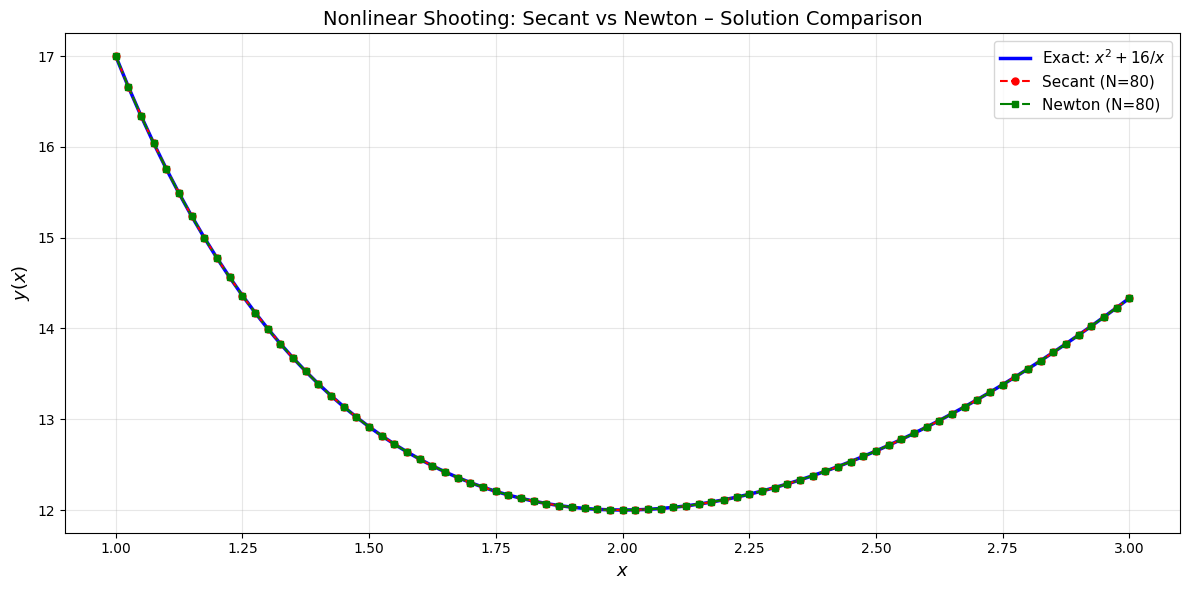

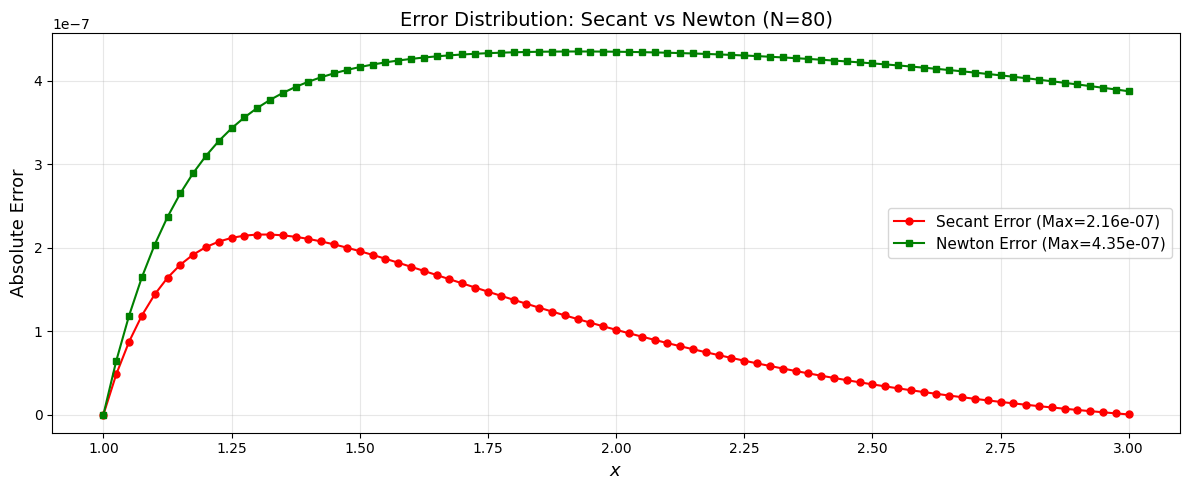

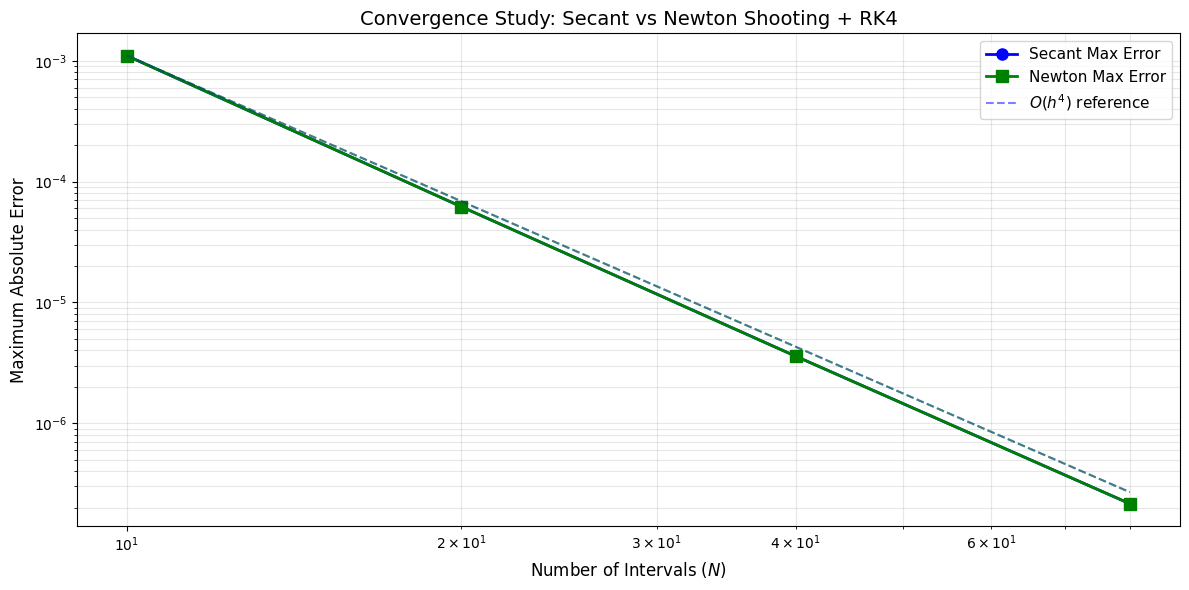

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ────────────────────────────────────────────────
# Nonlinear BVP
# y'' = (32 + 2x³ - y·y') / 8,  1 < x < 3
# BCs: y(1) = 17,  y(3) = 43/3
# Exact: y(x) = x² + 16/x
# ────────────────────────────────────────────────

# Exact solution
def y_exact(x):
    return x**2 + 16/x

# Nonlinear ODE: y'' = f(x, y, y')
def f(x, y, yp):
    return (32 + 2*x**3 - y*yp) / 8

# Domain and boundary conditions
a, b = 1.0, 3.0
alpha = y_exact(a)  # = 17
beta  = y_exact(b)  # = 43/3

# ────────────────────────────────────────────────
# RHS for system Y = [y, y']
# ────────────────────────────────────────────────
def rhs(t, Y):
    y, yp = Y
    return np.array([yp, f(t, y, yp)])

# ────────────────────────────────────────────────
# Manual RK4 IVP Solver
# ────────────────────────────────────────────────
def solve_ivp_rk4(s, N, a=a, b=b, alpha=alpha):
    x_grid = np.linspace(a, b, N+1)
    Y_sol = np.zeros((2, N+1))
    Y_sol[:, 0] = [alpha, s]
    
    for i in range(N):
        x = x_grid[i]
        h_step = x_grid[i+1] - x_grid[i]
        Y_curr = Y_sol[:, i]
        
        k1 = rhs(x, Y_curr)
        k2 = rhs(x + h_step/2, Y_curr + h_step * k1 / 2)
        k3 = rhs(x + h_step/2, Y_curr + h_step * k2 / 2)
        k4 = rhs(x + h_step,   Y_curr + h_step * k3)
        
        Y_sol[:, i+1] = Y_curr + (h_step / 6) * (k1 + 2*k2 + 2*k3 + k4)
    
    return x_grid, Y_sol[0, :], Y_sol[1, :]

# ────────────────────────────────────────────────
# Variational Equation for Newton's Method
# Solves: z'' = ∂f/∂y * z + ∂f/∂y' * z',  z(a)=0, z'(a)=1
# This gives dφ/ds = z(b)
# ────────────────────────────────────────────────
def rhs_variational(t, Y, Y_main):
    """ Variational equation RHS  Y = [z, z'] where z = ∂y/∂s  Y_main = [y, y'] from main IVP """
    y, yp = Y_main
    z, zp = Y
    
    # ∂f/∂y = -y'/8
    # ∂f/∂y' = -y/8
    df_dy = -yp / 8
    df_dyp = -y / 8
    
    zpp = df_dy * z + df_dyp * zp
    return np.array([zp, zpp])

# ────────────────────────────────────────────────
# Nonlinear Shooting using Secant Method
# ────────────────────────────────────────────────
def shooting_secant(N, s0, s1, beta, tol=1e-9, max_iter=10):
    
    def phi(s):
        _, y_vals, _ = solve_ivp_rk4(s, N)
        return y_vals[-1] - beta
    
    Phi0, Phi1 = phi(s0), phi(s1)
    iter_count = 0
    
    if abs(Phi0) < tol:
        x, y_approx, _ = solve_ivp_rk4(s0, N)
        return s0, x, y_approx, 0, 2  # 2 IVP solves for initial Phi0, Phi1
    
    if abs(Phi1) < tol:
        x, y_approx, _ = solve_ivp_rk4(s1, N)
        return s1, x, y_approx, 1, 2
    
    ivp_calls = 2  # Initial Phi0, Phi1
    
    for k in range(max_iter):
        iter_count = k + 1
        if abs(Phi1 - Phi0) < 1e-14:
            break
        
        s_new = s1 - Phi1 * (s1 - s0) / (Phi1 - Phi0)
        Phi_new = phi(s_new)
        ivp_calls += 1
        
        s0, Phi0 = s1, Phi1
        s1, Phi1 = s_new, Phi_new
        
        if abs(Phi1) < tol:
            break
    
    x, y_approx, _ = solve_ivp_rk4(s1, N)
    ivp_calls += 1  # Final solution
    
    return s1, x, y_approx, iter_count, ivp_calls

# ────────────────────────────────────────────────
# Nonlinear Shooting using Newton's Method
# ────────────────────────────────────────────────
def shooting_newton(N, s0, beta, tol=1e-5, max_iter=10):
    """ Newton's method requires solving variational equation to compute dφ/ds = z(b) where z = ∂y/∂s
    """
    
    def phi_and_dphi(s):
        """Returns φ(s) and φ'(s) by solving main + variational IVPs"""
        x_grid = np.linspace(a, b, N+1)
        
        # Main IVP: Y = [y, y']
        Y_main = np.zeros((2, N+1))
        Y_main[:, 0] = [alpha, s]
        
        # Variational IVP: Z = [z, z'] where z = ∂y/∂s
        Z = np.zeros((2, N+1))
        Z[:, 0] = [0.0, 1.0]  # z(a)=0, z'(a)=1
        
        for i in range(N):
            x = x_grid[i]
            h_step = x_grid[i+1] - x_grid[i]
            Y_curr = Y_main[:, i]
            Z_curr = Z[:, i]
            
            # Main RK4
            k1 = rhs(x, Y_curr)
            k2 = rhs(x + h_step/2, Y_curr + h_step * k1 / 2)
            k3 = rhs(x + h_step/2, Y_curr + h_step * k2 / 2)
            k4 = rhs(x + h_step,   Y_curr + h_step * k3)
            Y_main[:, i+1] = Y_curr + (h_step / 6) * (k1 + 2*k2 + 2*k3 + k4)
            
            # Variational RK4 (coupled with main solution)
            v1 = rhs_variational(x, Z_curr, Y_curr)
            v2 = rhs_variational(x + h_step/2, Z_curr + h_step * v1 / 2, 
                                 Y_curr + h_step * k1 / 2)
            v3 = rhs_variational(x + h_step/2, Z_curr + h_step * v2 / 2,
                                 Y_curr + h_step * k2 / 2)
            v4 = rhs_variational(x + h_step, Z_curr + h_step * v3,
                                 Y_curr + h_step * k3)
            Z[:, i+1] = Z_curr + (h_step / 6) * (v1 + 2*v2 + 2*v3 + v4)
        
        phi_val = Y_main[0, -1] - beta
        dphi_val = Z[0, -1]  # z(b) = ∂y(b)/∂s
        
        return phi_val, dphi_val, x_grid, Y_main[0, :]
    
    s = s0
    ivp_calls = 0
    iter_count = 0
    
    for k in range(max_iter):
        iter_count = k + 1
        Phi, dPhi, x_grid, y_approx = phi_and_dphi(s)
        ivp_calls += 1  # Each Newton step solves 2 coupled IVPs
        
        if abs(Phi) < tol:
            break
        if abs(dPhi) < 1e-14:
            print(f"Warning: dφ/ds too small at iter {k}")
            break
        
        s = s - Phi / dPhi
    
    return s, x_grid, y_approx, iter_count, ivp_calls

# ────────────────────────────────────────────────
# COMPARISON STUDY
# ────────────────────────────────────────────────
Ns = [10, 20, 40, 80]
tol = 1e-9
max_iter = 10

# Initial guesses
s0_secant = -12.0
s1_secant = -16.0
s0_newton = -14.0  # Newton needs only one initial guess

print("=" * 85)
print("NONLINEAR SHOOTING: SECANT vs NEWTON METHOD COMPARISON")
print("=" * 85)
print(f"ODE: y'' = (32 + 2x³ - y·y')/8,  x ∈ [1,3]")
print(f"Exact: y(x) = x² + 16/x")
print(f"BCs: y(1)={alpha}, y(3)={beta:.6f}")
print(f"Tolerance: {tol}, Max Iter: {max_iter}")
print(f"Initial guesses: Secant(s0={s0_secant}, s1={s1_secant}), Newton(s0={s0_newton})")
print("=" * 85)

# Store results
results_secant = []
results_newton = []

# ────────────────────────────────────────────────
# Table 1: Secant Method Results
# ────────────────────────────────────────────────
print("\n" + "─" * 85)
print("SECANT METHOD RESULTS")
print("─" * 85)
print(f"{'N':<4} | {'s*':<14} | {'Iter':<5} | {'IVP Calls':<10} | {'Max Error':<12} | {'Order':<6}")
print("-" * 85)

for N in Ns:
    s_star, x_vals, y_num, iters, ivp_calls = shooting_secant(
        N, s0=s0_secant, s1=s1_secant, beta=beta, tol=tol, max_iter=max_iter
    )
    y_ex = y_exact(x_vals)
    max_err = np.max(np.abs(y_ex - y_num))
    results_secant.append({'N': N, 's*': s_star, 'iters': iters, 
                           'ivp_calls': ivp_calls, 'error': max_err})
    
    if len(results_secant) == 1:
        order_str = "  -  "
    else:
        order = np.log(results_secant[-2]['error'] / results_secant[-1]['error']) / np.log(2)
        order_str = f"{order:.3f}"
    
    print(f"{N:<4} | {s_star:<14.8f} | {iters:<5} | {ivp_calls:<10} | {max_err:<12.4e} | {order_str:<6}")

# ────────────────────────────────────────────────
# Table 2: Newton Method Results
# ────────────────────────────────────────────────
print("\n" + "─" * 85)
print("NEWTON METHOD RESULTS")
print("─" * 85)
print(f"{'N':<4} | {'s*':<14} | {'Iter':<5} | {'IVP Calls':<10} | {'Max Error':<12} | {'Order':<6}")
print("-" * 85)

for N in Ns:
    s_star, x_vals, y_num, iters, ivp_calls = shooting_newton(
        N, s0=s0_newton, beta=beta, tol=tol, max_iter=max_iter
    )
    y_ex = y_exact(x_vals)
    max_err = np.max(np.abs(y_ex - y_num))
    results_newton.append({'N': N, 's*': s_star, 'iters': iters, 
                           'ivp_calls': ivp_calls, 'error': max_err})
    
    if len(results_newton) == 1:
        order_str = "  -  "
    else:
        order = np.log(results_newton[-2]['error'] / results_newton[-1]['error']) / np.log(2)
        order_str = f"{order:.3f}"
    
    print(f"{N:<4} | {s_star:<14.8f} | {iters:<5} | {ivp_calls:<10} | {max_err:<12.4e} | {order_str:<6}")

# ────────────────────────────────────────────────
# Table 3: Side-by-Side Comparison (N=80)
# ────────────────────────────────────────────────
print("\n" + "=" * 85)
print("DIRECT COMPARISON (N=80)")
print("=" * 85)
print(f"{'Metric':<25} | {'Secant':<15} | {'Newton':<15} | {'Advantage':<15}")
print("-" * 85)

idx = 3  # N=80 is at index 3
sec = results_secant[idx]
new = results_newton[idx]

metrics = [
    ('Optimal slope s*', f"{sec['s*']:.8f}", f"{new['s*']:.8f}", 
     "Same" if abs(sec['s*']-new['s*']) < 1e-8 else "Different"),
    ('Iterations', f"{sec['iters']}", f"{new['iters']}", 
     "Secant" if sec['iters'] < new['iters'] else "Newton"),
    ('IVP Solves', f"{sec['ivp_calls']}", f"{new['ivp_calls']}", 
     "Secant" if sec['ivp_calls'] < new['ivp_calls'] else "Newton"),
    ('Max Error', f"{sec['error']:.4e}", f"{new['error']:.4e}", 
     "Secant" if sec['error'] < new['error'] else "Newton"),
]

for metric, sec_val, new_val, adv in metrics:
    print(f"{metric:<25} | {sec_val:<15} | {new_val:<15} | {adv:<15}")

# ────────────────────────────────────────────────
# Summary: Convergence Orders
# ────────────────────────────────────────────────
print("\n" + "=" * 85)
print("CONVERGENCE ORDER COMPARISON")
print("=" * 85)
print(f"{'N Range':<15} | {'Secant Order':<15} | {'Newton Order':<15}")
print("-" * 85)

for i in range(len(Ns)-1):
    if results_secant[i]['error'] > 1e-14 and results_secant[i+1]['error'] > 1e-14:
        order_sec = np.log(results_secant[i]['error'] / results_secant[i+1]['error']) / np.log(2)
    else:
        order_sec = float('nan')
    
    if results_newton[i]['error'] > 1e-14 and results_newton[i+1]['error'] > 1e-14:
        order_new = np.log(results_newton[i]['error'] / results_newton[i+1]['error']) / np.log(2)
    else:
        order_new = float('nan')
    
    print(f"N={Ns[i]:2d} → {Ns[i+1]:2d}     | {order_sec:<15.4f} | {order_new:<15.4f}")

# ────────────────────────────────────────────────
# PLOTS
# ────────────────────────────────────────────────

# Plot 1: Solution comparison (both methods vs exact)
N_plot = 80
s_sec, x_sec, y_sec, _, _ = shooting_secant(N_plot, s0_secant, s1_secant, beta)
s_new, x_new, y_new, _, _ = shooting_newton(N_plot, s0_newton, beta)
y_ex_plot = y_exact(x_sec)

plt.figure(figsize=(12, 6))
plt.plot(x_sec, y_ex_plot, 'b-', lw=2.5, label='Exact: $x^2 + 16/x$')
plt.plot(x_sec, y_sec, 'ro--', markersize=5, lw=1.5, label=f'Secant (N={N_plot})')
plt.plot(x_new, y_new, 'gs-.', markersize=5, lw=1.5, label=f'Newton (N={N_plot})')
plt.xlabel('$x$', fontsize=13)
plt.ylabel('$y(x)$', fontsize=13)
plt.title('Nonlinear Shooting: Secant vs Newton – Solution Comparison', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Plot 2: Error comparison
error_sec = np.abs(y_ex_plot - y_sec)
error_new = np.abs(y_ex_plot - y_new)

plt.figure(figsize=(12, 5))
plt.plot(x_sec, error_sec, 'ro-', markersize=5, lw=1.5, label=f'Secant Error (Max={np.max(error_sec):.2e})')
plt.plot(x_new, error_new, 'gs-', markersize=5, lw=1.5, label=f'Newton Error (Max={np.max(error_new):.2e})')
plt.xlabel('$x$', fontsize=13)
plt.ylabel('Absolute Error', fontsize=13)
plt.title('Error Distribution: Secant vs Newton (N=80)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Plot 3: Convergence study (log-log)
Ns_arr = np.array(Ns)
errors_sec = np.array([r['error'] for r in results_secant])
errors_new = np.array([r['error'] for r in results_newton])

plt.figure(figsize=(12, 6))
plt.loglog(Ns_arr, errors_sec, 'bo-', lw=2, markersize=8, label='Secant Max Error')
plt.loglog(Ns_arr, errors_new, 'gs-', lw=2, markersize=8, label='Newton Max Error')

# Reference lines
E_ref_sec = errors_sec[0] * (Ns_arr[0] / Ns_arr)**4
E_ref_new = errors_new[0] * (Ns_arr[0] / Ns_arr)**4
plt.loglog(Ns_arr, E_ref_sec, 'b--', alpha=0.5, label='$O(h^4)$ reference')
plt.loglog(Ns_arr, E_ref_new, 'g--', alpha=0.5)

plt.xlabel('Number of Intervals ($N$)', fontsize=12)
plt.ylabel('Maximum Absolute Error', fontsize=12)
plt.title('Convergence Study: Secant vs Newton Shooting + RK4', fontsize=14)
plt.grid(True, which='both', alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


## 3.2. Finite Difference Method for BVPs

#### Finite Difference Approximations

To approximate the first derivative $u'(\bar{x})$ at the point $\bar{x} = 1$, we consider three finite difference formulas:

$$
D_+ u(\bar{x}) = \frac{1}{h} \bigl[ u(\bar{x} + h) - u(\bar{x}) \bigr] \quad \text{(Forward difference)}
$$

$$
D_0 u(\bar{x}) = \frac{1}{2h} \bigl[ u(\bar{x} + h) - u(\bar{x} - h) \bigr] \quad \text{(Central difference)}
$$

$$
D_3 u(\bar{x}) = \frac{1}{6h} \bigl[ 2u(\bar{x} + h) + 3u(\bar{x}) - 6u(\bar{x} - h) + u(\bar{x} - 2h) \bigr]  
        \text{(Third-order backward difference)} $$

We evaluate these approximations on the following test functions:

$$
\begin{aligned}
    u_1(x) &= \sin(10x), \\
    u_2(x) &= 4x^3 - 12x^2 + 14x - 4, \\
    u_3(x) &= |x - 1.001|^{3/2}.
\end{aligned}
$$

For each function, the derivative is approximated at $x = 1$ using step sizes $h = 10^{-j}$ for $j = 1, 2, \dots, 7$. This allows us to study:

- The observed order of convergence,
- The effect of function smoothness on accuracy,
- The onset of roundoff error as $h$ becomes very small.
```


#### Theoretical Accuracy

We analyze the local truncation errors of three finite difference formulas for the first derivative $u'(x)$, assuming $u$ is sufficiently smooth (e.g., $u \in C^k$ in a neighborhood of $x$). All expansions are performed via Taylor series about the point $x$, with step size $h > 0$.

##### Forward Difference

The forward difference approximation is

$$
D_+ u(x) = \frac{u(x+h) - u(x)}{h}.
$$

Using the Taylor expansion

$$
u(x+h) = u(x) + h u'(x) + \frac{h^2}{2} u''(x) + \frac{h^3}{6} u'''(x) + \frac{h^4}{24} u^{(4)}(x) + O(h^5),
$$

we obtain

$$
\begin{align*}
    D_+ u(x) 
    &= \frac{1}{h} \Bigl[ h u'(x) + \frac{h^2}{2} u''(x) + \frac{h^3}{6} u'''(x) + \frac{h^4}{24} u^{(4)}(x) + O(h^5) \Bigr] \\
    &= u'(x) + \frac{h}{2} u''(x) + \frac{h^2}{6} u'''(x) + \frac{h^3}{24} u^{(4)}(x) + O(h^4).
\end{align*}
$$

Hence, the truncation error is

$$
D_+ u(x) - u'(x) = \frac{h}{2}\, u''(x) + \frac{h^2}{6}\, u'''(x) + \frac{h^3}{24}\, u^{(4)}(x) + O(h^4)
$$

with leading term $\tfrac{h}{2} u''(x)$. Therefore, $D_+$ is **first-order accurate**:

$$
D_+ u(x) - u'(x) = O(h).
$$

##### Central Difference

The central difference approximation is

$$
D_0 u(x) = \frac{u(x+h) - u(x-h)}{2h}.
$$

Taylor expansions about $x$:

$$
\begin{align*}
    u(x+h) &= u + h u' + \frac{h^2}{2} u'' + \frac{h^3}{6} u''' + \frac{h^4}{24} u^{(4)} + \frac{h^5}{120} u^{(5)} + O(h^6), \\
    u(x-h) &= u - h u' + \frac{h^2}{2} u'' - \frac{h^3}{6} u''' + \frac{h^4}{24} u^{(4)} - \frac{h^5}{120} u^{(5)} + O(h^6).
\end{align*}
$$

Subtracting:

$$
u(x+h) - u(x-h) = 2h u' + \frac{h^3}{3} u''' + \frac{h^5}{60} u^{(5)} + O(h^7),
$$

so

$$
D_0 u(x) = u' + \frac{h^2}{6} u''' + \frac{h^4}{120} u^{(5)} + O(h^6).
$$

Thus,

$$
D_0 u(x) - u'(x) = \frac{h^2}{6}\, u'''(x) + \frac{h^4}{120}\, u^{(5)}(x) + O(h^6)
$$

with leading term $\tfrac{h^2}{6} u'''(x)$. Therefore, $D_0$ is **second-order accurate**:

$$
D_0 u(x) - u'(x) = O(h^2).
$$

##### Third-Order Approximation

Consider the four-point formula

$$
D_3 u(x) = \frac{2\,u(x+h) + 3\,u(x) - 6\,u(x-h) + u(x-2h)}{6h}.
$$

Although it uses a point ahead ($x+h$), it is often referred to as a "third-order backward-type" scheme due to its asymmetry (three points behind, one ahead).

We expand each term about $x$:

$$
\begin{align*}
    u(x+h) &= u + h u' + \frac{h^2}{2} u'' + \frac{h^3}{6} u''' + \frac{h^4}{24} u^{(4)} + \frac{h^5}{120} u^{(5)} + O(h^6), \\
    u(x-h) &= u - h u' + \frac{h^2}{2} u'' - \frac{h^3}{6} u''' + \frac{h^4}{24} u^{(4)} - \frac{h^5}{120} u^{(5)} + O(h^6), \\
    u(x-2h) &= u - 2h u' + 2h^2 u'' - \frac{4h^3}{3} u''' + \frac{2h^4}{3} u^{(4)} - \frac{4h^5}{15} u^{(5)} + O(h^6).
\end{align*}
$$

Compute the numerator:

$$
\begin{align*}
    2u(x+h) + 3u(x) - 6u(x-h) + u(x-2h) &= \bigl[6h\bigr] u' + \bigl[0\bigr] h^2 u'' + \bigl[0\bigr] h^3 u'''  + \left[\frac{1}{2} h^4\right] u^{(4)} - \left[\frac{1}{5} h^5\right] u^{(5)} + O(h^6).
\end{align*}
$$

Dividing by $6h$:

$$
D_3 u(x) = u'(x) + \frac{1}{12} h^3 u^{(4)}(x) - \frac{1}{30} h^4 u^{(5)}(x) + O(h^5).
$$

Hence,

$$
D_3 u(x) - u'(x) = \frac{1}{12}\, h^3\, u^{(4)}(x) + O(h^4)
$$

with leading term $\tfrac{1}{12} h^3 u^{(4)}(x)$. Therefore, $D_3$ is **third-order accurate**:

$$
D_3 u(x) - u'(x) = O(h^3).
$$

#### Summary of Accuracy

*Finite difference approximations for $u'(x)$: formulas, stencils, leading error terms, and orders.*

| Scheme | Formula | Leading Error Term | Order |
| :--- | :--- | :--- | :--- |
| $D_+$ | $\dfrac{u(x+h)-u(x)}{h}$ | $\dfrac{h}{2} u''(x)$ | $O(h)$ |
| $D_0$ | $\dfrac{u(x+h)-u(x-h)}{2h}$ | $\dfrac{h^2}{6} u'''(x)$ | $O(h^2)$ |
| $D_3$ | $\dfrac{2u(x+h)+3u(x)-6u(x-h)+u(x-2h)}{6h}$ | $\dfrac{h^3}{12} u^{(4)}(x)$ | $O(h^3)$ |
```

Consequently, as $h \to 0$, we expect the errors to behave like:

$$
\text{Error}(D_+) \propto h, \qquad
\text{Error}(D_0) \propto h^2, \qquad
\text{Error}(D_3) \propto h^3,
$$

provided the solution is sufficiently smooth and roundoff effects are negligible.


#### Numerical Test Results

#### First Test Function: $u_1(x) = \sin(10x)$

This function is smooth and infinitely differentiable. The exact derivative at $x = 1$ is

$$
u_1'(1) = 10 \cos(10) \approx -8.390718.
$$

The table below reports the absolute errors in the three finite difference approximations for decreasing values of $h$.

| $h$ | $|D_+ - u'|$ | $|D_0 - u'|$ | $|D_3 - u'|$ |
|------|--------------|--------------|--------------|
| $1.0 \times 10^{-1}$ | $3.8310 \times 10^{0}$ | $1.3302 \times 10^{0}$ | $1.3495 \times 10^{-1}$ |
| $1.0 \times 10^{-2}$ | $2.8576 \times 10^{-1}$ | $1.3978 \times 10^{-2}$ | $4.2466 \times 10^{-4}$ |
| $1.0 \times 10^{-3}$ | $2.7341 \times 10^{-2}$ | $1.3984 \times 10^{-4}$ | $4.5055 \times 10^{-7}$ |
| $1.0 \times 10^{-4}$ | $2.7215 \times 10^{-3}$ | $1.3985 \times 10^{-6}$ | $4.4782 \times 10^{-10}$ |
| $1.0 \times 10^{-5}$ | $2.7202 \times 10^{-4}$ | $1.4007 \times 10^{-8}$ | $2.4212 \times 10^{-11}$ |
| $1.0 \times 10^{-6}$ | $2.7201 \times 10^{-5}$ | $4.1279 \times 10^{-10}$ | $2.4625 \times 10^{-10}$ |
| $1.0 \times 10^{-7}$ | $2.7116 \times 10^{-6}$ | $6.9743 \times 10^{-10}$ | $4.2986 \times 10^{-9}$ |

**Observations:**

- For moderate $h$ (e.g., $h \geq 10^{-4}$), the errors decrease at the expected rates: roughly by a factor of 10 for $D_+$, 100 for $D_0$, and 1000 for $D_3$ when $h$ is reduced by a factor of 10.
- As $h$ becomes very small ($h \leq 10^{-6}$), roundoff errors dominate, especially for the higher-order method $D_3$, whose error begins to increase due to cancellation in finite-precision arithmetic.
- The central difference $D_0$ remains accurate down to $h = 10^{-5}$, after which roundoff effects become noticeable.



For larger $h$, the errors decrease as expected: by a factor of ~10 for $D_+$, ~100 for $D_0$, and ~1000 for $D_3$. However, for $h < 10^{-5}$, roundoff errors dominate due to cancellation in finite precision arithmetic. The minimal achievable error is about $10^{-9}$–$10^{-10}$, beyond which accuracy degrades.

**Note:** In solving differential equations, such small $h$ are rarely used, so roundoff is typically not an issue.

---

##### Second Test Function: $u_2(x) = 4x^3 - 12x^2 + 14x - 4$

This is a cubic polynomial. The exact derivative at $x = 1$ is:

$$
u_2'(1) = 12(1)^2 - 24(1) + 14 = 2
$$

| $h$ | $D_+$ Error | $D_0$ Error | $D_3$ Error |
|------|-------------|-------------|-------------|
| $1.0 \times 10^{-1}$ | $4.0000 \times 10^{-2}$ | $4.0000 \times 10^{-2}$ | $7.5495 \times 10^{-15}$ |
| $1.0 \times 10^{-2}$ | $4.0000 \times 10^{-4}$ | $4.0000 \times 10^{-4}$ | $-1.2879 \times 10^{-14}$ |
| $1.0 \times 10^{-3}$ | $4.0000 \times 10^{-6}$ | $4.0000 \times 10^{-6}$ | $9.6412 \times 10^{-13}$ |
| $1.0 \times 10^{-4}$ | $3.9999 \times 10^{-8}$ | $4.0008 \times 10^{-8}$ | $1.3102 \times 10^{-11}$ |
| $1.0 \times 10^{-5}$ | $4.5719 \times 10^{-10}$ | $5.0160 \times 10^{-10}$ | $1.4633 \times 10^{-10}$ |
| $1.0 \times 10^{-6}$ | $-1.4968 \times 10^{-9}$ | $-6.0862 \times 10^{-10}$ | $-1.6504 \times 10^{-11}$ |
| $1.0 \times 10^{-7}$ | $5.6086 \times 10^{-9}$ | $-3.2732 \times 10^{-9}$ | $-1.2155 \times 10^{-8}$ |


**Observations:**

- $D_+$ and $D_0$ errors behave similarly because $u_2''(1) = 0$, eliminating the leading error term in $D_+$.
- $D_3$ is nearly exact because $u_2$ is a cubic polynomial, and $D_3$ is designed to be exact for polynomials up to degree 3.
- Small nonzero errors in $D_3$ are due to roundoff.

---

##### Third Test Function: $u_3(x) = |x - 1.001|^{3/2}$

This function is not smooth at $x = 1.001$. Its first derivative behaves like $|x - 1.001|^{1/2}$, and higher derivatives blow up at this point.

Exact derivative at $x = 1$:

$$
u_3'(1) = \frac{3}{2} |1 - 1.001|^{1/2} \cdot (-1) = -\frac{3}{2} \sqrt{0.001} \approx -0.047434
$$

| $h$ | $D_+$ Error | $D_0$ Error | $D_3$ Error |
|------|-------------|-------------|-------------|
| $1.0 \times 10^{-1}$ | $3.5861 \times 10^{-1}$ | $4.2691 \times 10^{-2}$ | $-1.9368 \times 10^{-2}$ |
| $1.0 \times 10^{-2}$ | $1.2965 \times 10^{-1}$ | $3.2440 \times 10^{-2}$ | $1.2827 \times 10^{-2}$ |
| $1.0 \times 10^{-3}$ | $1.5811 \times 10^{-2}$ | $2.7128 \times 10^{-3}$ | $1.1890 \times 10^{-3}$ |
| $1.0 \times 10^{-4}$ | $1.2064 \times 10^{-3}$ | $1.9801 \times 10^{-5}$ | $1.3533 \times 10^{-6}$ |
| $1.0 \times 10^{-5}$ | $1.1878 \times 10^{-4}$ | $1.9765 \times 10^{-7}$ | $1.4678 \times 10^{-9}$ |
| $1.0 \times 10^{-6}$ | $1.1861 \times 10^{-5}$ | $1.9777 \times 10^{-9}$ | $9.9724 \times 10^{-13}$ |
| $1.0 \times 10^{-7}$ | $1.1858 \times 10^{-6}$ | $1.8403 \times 10^{-11}$ | $1.6190 \times 10^{-11}$ |



For $h > 10^{-3}$, the difference stencils cross the singularity at $x = 1.001$, violating smoothness assumptions. Thus, convergence is poor. For $h < 10^{-3}$, all stencil points lie on the smooth side ($x < 1.001$), and expected convergence rates are observed until roundoff dominates.
```


Test 1: u_1(x) = \sin(10x)
Derivative errors at x = 1.000 (kink at 1.001)
           h     D_+ error     D_0 error     D_3 error
-----------------------------------------------------------------
  1.0000e-01    3.8310e+00    1.3302e+00   -1.3495e-01
  1.0000e-02    2.8576e-01    1.3978e-02   -4.2466e-04
  1.0000e-03    2.7341e-02    1.3984e-04   -4.5055e-07
  1.0000e-04    2.7215e-03    1.3985e-06   -4.4782e-10
  1.0000e-05    2.7202e-04    1.4007e-08    2.4212e-11
  1.0000e-06    2.7201e-05    4.1279e-10    2.4625e-10
  1.0000e-07    2.7116e-06   -1.2525e-09    3.5584e-09


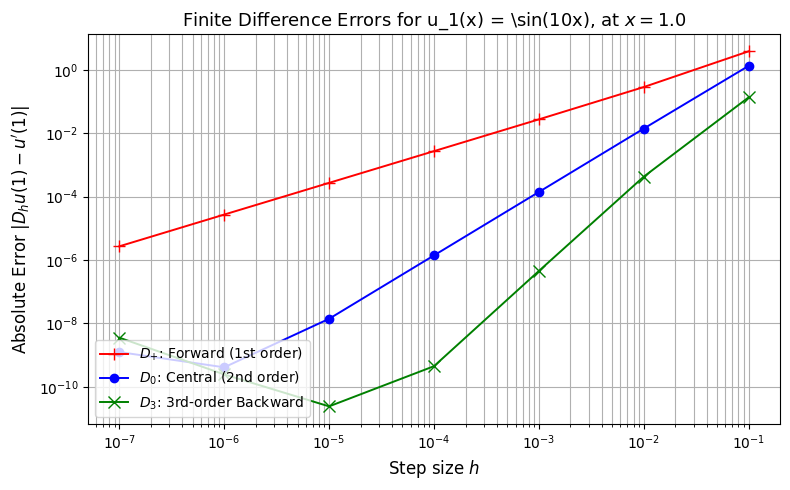


Test 2: u_2(x) = 4x^3 - 12x^2 + 14x - 4
Derivative errors at x = 1.000 (kink at 1.001)
           h     D_+ error     D_0 error     D_3 error
-----------------------------------------------------------------
  1.0000e-01    4.0000e-02    4.0000e-02    7.5495e-15
  1.0000e-02    4.0000e-04    4.0000e-04   -1.2879e-14
  1.0000e-03    4.0000e-06    4.0000e-06    9.6412e-13
  1.0000e-04    3.9999e-08    4.0008e-08    1.3102e-11
  1.0000e-05    4.5719e-10    5.0160e-10    1.4633e-10
  1.0000e-06   -1.4968e-09   -6.0862e-10   -1.6504e-11
  1.0000e-07    5.6086e-09   -3.2732e-09   -1.2155e-08


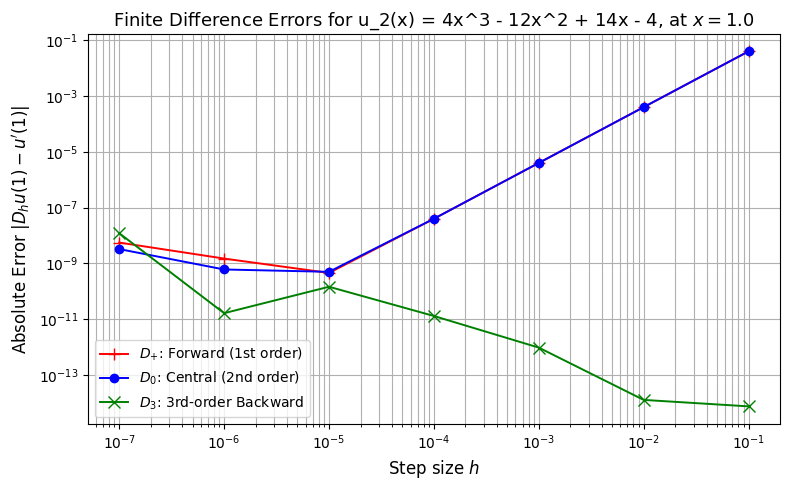


Test 3: u_3(x) = |x - 1.001|^{3/2}
Derivative errors at x = 1.000 (kink at 1.001)
           h     D_+ error     D_0 error     D_3 error
-----------------------------------------------------------------
  1.0000e-01    3.5861e-01    4.2691e-02   -1.9368e-02
  1.0000e-02    1.2965e-01    3.2440e-02    1.2827e-02
  1.0000e-03    1.5811e-02    2.7128e-03    1.1890e-03
  1.0000e-04    1.2064e-03    1.9801e-05    1.3533e-06
  1.0000e-05    1.1878e-04    1.9765e-07    1.4678e-09
  1.0000e-06    1.1861e-05    1.9777e-09    9.9724e-13
  1.0000e-07    1.1858e-06    1.8403e-11    1.6190e-11


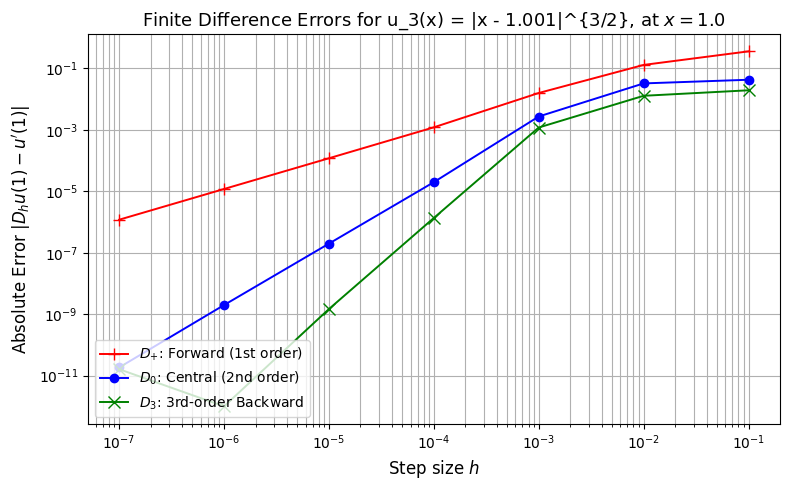

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import re

x0 = 1.0  # Safe evaluation point (u3 is C^1 here since 1 < 1.001)
a = 1.001
nh = 7

# --- Functions and Exact Derivatives ---
# u1(x) = sin(10x)
u1 = lambda x: np.sin(10 * x)
up1 = lambda x: 10 * np.cos(10 * x)

# u2(x) = 4x^3 - 12x^2 + 14x - 4
u2 = lambda x: 4 * x**3 - 12 * x**2 + 14 * x - 4
up2 = lambda x: 12 * x**2 - 24 * x + 14

# u3(x) = |x - 1.001|^(3/2)
u3 = lambda x: np.abs(x - a)**(1.5)
up3 = lambda x: 1.5 * np.sign(x - a) * np.sqrt(np.abs(x - a))

# Store tests in a list of tuples: (function, derivative, label)
tests = [
    (u1, up1, r'u_1(x) = \sin(10x)'),
    (u2, up2, r'u_2(x) = 4x^3 - 12x^2 + 14x - 4'),
    (u3, up3, r'u_3(x) = |x - 1.001|^{3/2}')
]

# --- Main Analysis Loop ---
for t, (u, up, label) in enumerate(tests):
    print('\n' + '=' * 65)
    print(f'Test {t + 1}: {label}')
    print(f'Derivative errors at x = {x0:.3f} (kink at {a})')
    print(f'{"h":>12}  {"D_+ error":>12}  {"D_0 error":>12}  {"D_3 error":>12}')
    print('-' * 65)   
    
    errors = np.zeros((nh, 4))   
    
    for i in range(1, nh + 1):
        h = 10**(-i)
        
        # Evaluate function at required points
        u_xph = u(x0 + h)      
        u_x   = u(x0)         
        u_xmh = u(x0 - h)      
        u_xm2h = u(x0 - 2*h)   
        
        # Finite Difference Schemes
        # Forward Difference
        D_plus = (u_xph - u_x) / h
        
        # Central Difference
        D_0 = (u_xph - u_xmh) / (2 * h)
        
        # 3-point/Asymmetric Scheme 
        D_3 = (2 * u_xph + 3 * u_x - 6 * u_xmh + u_xm2h) / (6 * h)
        
        # Exact Derivative
        d_exact = up(x0)
        
        # Store Errors
        errors[i-1, :] = [h, D_plus - d_exact, D_0 - d_exact, D_3 - d_exact]
        
        # Print Row
        print(f'{h:12.4e}  {errors[i-1, 1]:12.4e}  {errors[i-1, 2]:12.4e}  {errors[i-1, 3]:12.4e}')

    # --- Plotting ---
    plt.figure(figsize=(8, 5)) 
    
    h_vals = errors[:, 0]
    
    # Plot D_+
    plt.loglog(h_vals, np.abs(errors[:, 1]), 'r+-', linewidth=1.4, markersize=8,
               label=r'$D_{+}$: Forward (1st order)')
    
    # Plot D_0
    plt.loglog(h_vals, np.abs(errors[:, 2]), 'bo-', linewidth=1.4, markersize=6,
               label=r'$D_{0}$: Central (2nd order)')
    
    # Plot D_3
    plt.loglog(h_vals, np.abs(errors[:, 3]), 'gx-', linewidth=1.4, markersize=8,
               label=r'$D_{3}$: 3rd-order Backward')
    
    # Labels and Title
    clean_label = label 
    plt.title(f'Finite Difference Errors for {clean_label}, at $x = {x0}$', fontsize=13)
    plt.xlabel('Step size $h$', fontsize=12)
    plt.ylabel('Absolute Error $|D_h u(1) - u\'(1)|$', fontsize=12)
    
    # Legend and Grid
    plt.legend(loc='lower left')
    plt.grid(True, which="both", ls="-")
    plt.box(True)
    
    # Adjust layout to prevent cutoff
    plt.tight_layout()
    plt.show()

Finite difference methods achieve their theoretical convergence rates only when the solution is sufficiently smooth and $h$ is not too small.

Roundoff errors dominate for very small $h$, limiting achievable accuracy.

Singularities or nonsmooth points in the solution degrade convergence unless $h$ is small enough to resolve the smooth region.

Choosing the appropriate difference formula and step size is crucial in numerical methods for differential equations.

### 3.2.1. Finite Difference Method for Linear BVPs

The linear and nonlinear shooting methods for boundary value problems (BVPs) can suffer from numerical instability, particularly when the differential equation is convection-dominated (i.e., when the first-order term $p(x)u'(x)$ is large). In contrast, finite difference methods (FDM) offer better stability by directly discretizing the differential operator over the entire domain. While FDM requires solving a system of linear equations (and thus more computational effort), it avoids the sensitivity to initial guesses inherent in shooting methods.

Finite difference methods approximate derivatives using difference quotients. The choice of scheme affects both accuracy and stability. We consider two standard approaches: the **central difference scheme** and the **upwind scheme**.

Consider the linear second-order BVP:

$$
u''(x) + p(x) u'(x) + q(x) u(x) = f(x), \quad a < x < b,
$$

with boundary conditions

$$
u(a) = \alpha, \quad u(b) = \beta.
$$

We discretize the interval $[a, b]$ into $N+1$ equally spaced points:

$$
x_i = a + i h, \quad i = 0, 1, \dots, N, \quad h = \frac{b - a}{N}.
$$

Let $u_i \approx u(x_i)$. The goal is to approximate $u_i$ for $i = 1, 2, \dots, N-1$, with $u_0 = \alpha$, $u_N = \beta$.

##### Central Finite Difference Scheme

We use the following approximations:

- **First derivative:** 
$$
u'(x_i) \approx \frac{u_{i+1} - u_{i-1}}{2h} + O(h^2)
$$

- **Second derivative:** 
$$
u''(x_i) \approx \frac{u_{i+1} - 2u_i + u_{i-1}}{h^2} + O(h^2)
$$

Substitute into the BVP at $x = x_i$:

$$
\frac{u_{i+1} - 2u_i + u_{i-1}}{h^2}
+ p_i \cdot \frac{u_{i+1} - u_{i-1}}{2h}
+ q_i u_i = f_i,
$$

where $p_i = p(x_i)$, $q_i = q(x_i)$, $f_i = f(x_i)$.

Multiply through by $h^2$ and rearrange:

$$
\left(1 + \frac{h}{2} p_i\right) u_{i-1}
+ \left(-2 + h^2 q_i\right) u_i
+ \left(1 - \frac{h}{2} p_i\right) u_{i+1}
= h^2 f_i.
$$

#### Matrix Formulation

This leads to a tridiagonal system:

$$
A \mathbf{U} = \mathbf{b},
$$

where:
- $\mathbf{U} = [u_1, u_2, \dots, u_{N-1}]^T$
- $A$ is a tridiagonal matrix with entries:

$$
A_{i,i-1} = 1 + \frac{h}{2} p_i, \quad
A_{i,i} = -2 + h^2 q_i, \quad
A_{i,i+1} = 1 - \frac{h}{2} p_i
$$

(for $i = 1, \dots, N-1$, with $A_{1,0}$ and $A_{N-1,N}$ omitted).

The right-hand side vector $\mathbf{b}$ incorporates boundary conditions:

$$
b_1 = h^2 f_1 - \left(1 + \frac{h}{2} p_1\right) \alpha, \quad
b_{N-1} = h^2 f_{N-1} - \left(1 - \frac{h}{2} p_{N-1}\right) \beta,
$$

and $b_i = h^2 f_i$ for $i = 2, \dots, N-2$.

Thus:

$$
\mathbf{b} =
\begin{pmatrix}
f(x_1) h^2 - \left(1 + \frac{h}{2} p(x_1)\right) \alpha \\
f(x_2) h^2 \\
\vdots \\
f(x_{N-2}) h^2 \\
f(x_{N-1}) h^2 - \left(1 - \frac{h}{2} p(x_{N-1})\right) \beta
\end{pmatrix}
$$

#### Stability and Convergence

- **Accuracy**: The method is second-order accurate: $ \text{Error} = O(h^2) $ if $ p, q, f \in C^2[a,b] $.
- **Stability**: The scheme is stable if the matrix $ A $ is strictly diagonally dominant or an M-matrix.
- **Diagonal Dominance**: Requires:
  $$ |A_{i,i}| \geq |A_{i,i-1}| + |A_{i,i+1}| $$
  For central differences, this fails when $ |p(x_i)| $ is large. Specifically, instability occurs when the **Péclet number** $ \text{Pe}_i = \frac{|p(x_i)| h}{2} > 1 $.
- **Oscillations**: When $ \text{Pe}_i > 1 $, the solution may exhibit nonphysical oscillations due to loss of monotonicity.
- **Convergence**: If $ q(x) \geq 0 $ and $ p(x) $ is bounded, the method converges as $ h \to 0 $ with order $ O(h^2) $.

#### Upwind Finite Difference Scheme

When $|p(x)|$ is large (especially $|p(x)| \sim 1/h$), central differences become unstable. The **upwind scheme** uses a backward difference for $u'$ if $p(x) > 0$ (flow to the right), and forward if $p(x) < 0$ (flow to the left), mimicking the direction of information propagation.

#### Discretization

For $p_i \geq 0$: use backward difference

$$
u'(x_i) \approx \frac{u_i - u_{i-1}}{h}
\Rightarrow
\frac{u_{i+1} - 2u_i + u_{i-1}}{h^2}
+ p_i \frac{u_i - u_{i-1}}{h}
+ q_i u_i = f_i
$$

Multiply by $h^2$:

$$
(1 - h p_i) u_{i-1}
+ (-2 + h p_i + h^2 q_i) u_i
+ u_{i+1}
= h^2 f_i
$$

For $p_i < 0$: use forward difference

$$
u'(x_i) \approx \frac{u_{i+1} - u_i}{h}
\Rightarrow
u_{i-1}
+ (-2 - h p_i + h^2 q_i) u_i
+ (1 + h p_i) u_{i+1}
= h^2 f_i
$$

#### Matrix Formulation

The system is $A \mathbf{U} = \mathbf{b}$, with:

$$
A_{i,i-1} =
\begin{cases}
    1 - h p_i, & p_i \geq 0 \\
    1, & p_i < 0
\end{cases}
\quad
A_{i,i} =
\begin{cases}
    -2 + h p_i + h^2 q_i, & p_i \geq 0 \\
    -2 - h p_i + h^2 q_i, & p_i < 0
\end{cases}
\quad
A_{i,i+1} =
\begin{cases}
    1, & p_i \geq 0 \\
    1 + h p_i, & p_i < 0
\end{cases}
$$

Boundary terms:
- $b_1 = h^2 f_1 - A_{1,0} \alpha$
- $b_{N-1} = h^2 f_{N-1} - A_{N-1,N} \beta$

#### Stability and Convergence

- **Accuracy**: First-order: $O(h)$
- **Stability**: The upwind scheme is unconditionally stable for $q(x) \geq 0$
- **Diagonal Dominance**: If $q(x) \geq 0$, the matrix is diagonally dominant:
  $$
  |A_{i,i}| \geq |A_{i,i-1}| + |A_{i,i+1}|
  $$
  This ensures stability and prevents oscillations.
- **Monotonicity**: The discrete solution satisfies a maximum principle if $q(x) \geq 0$.


N	Error (Central)		C = Error*N^2	Error (Upwind)	C = Error*N
--------------------------------------------------------------------------------
16	3.93e-05		1.01e-02		3.93e-03		6.29e-02
32	9.83e-06		1.01e-02		1.93e-03		6.16e-02
64	2.46e-06		1.01e-02		9.53e-04		6.10e-02
128	6.14e-07		1.01e-02		4.74e-04		6.07e-02
256	1.54e-07		1.01e-02		2.37e-04		6.06e-02
512	3.84e-08		1.01e-02		1.18e-04		6.05e-02
1024	9.60e-09		1.01e-02		5.90e-05		6.04e-02


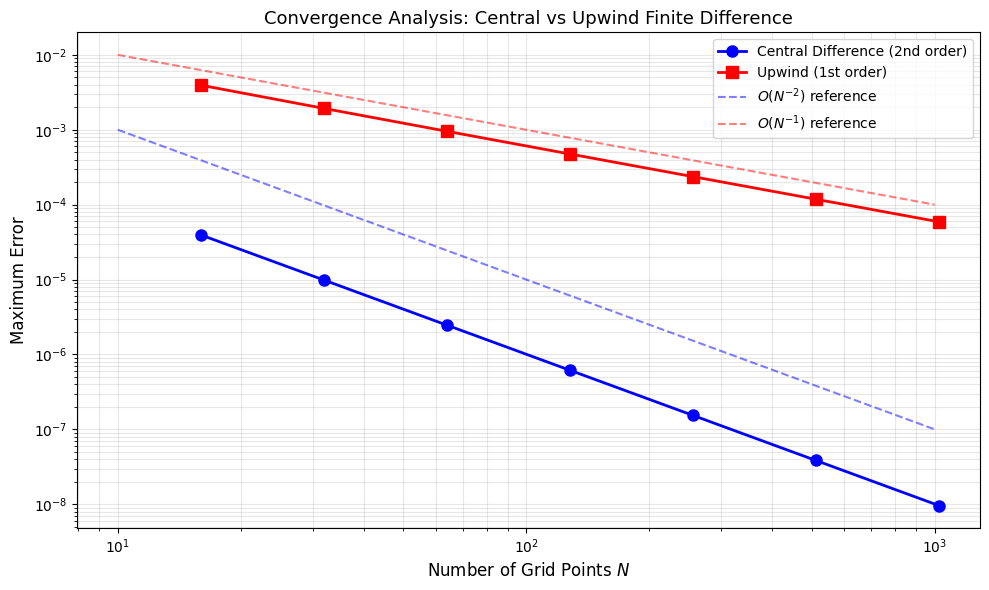

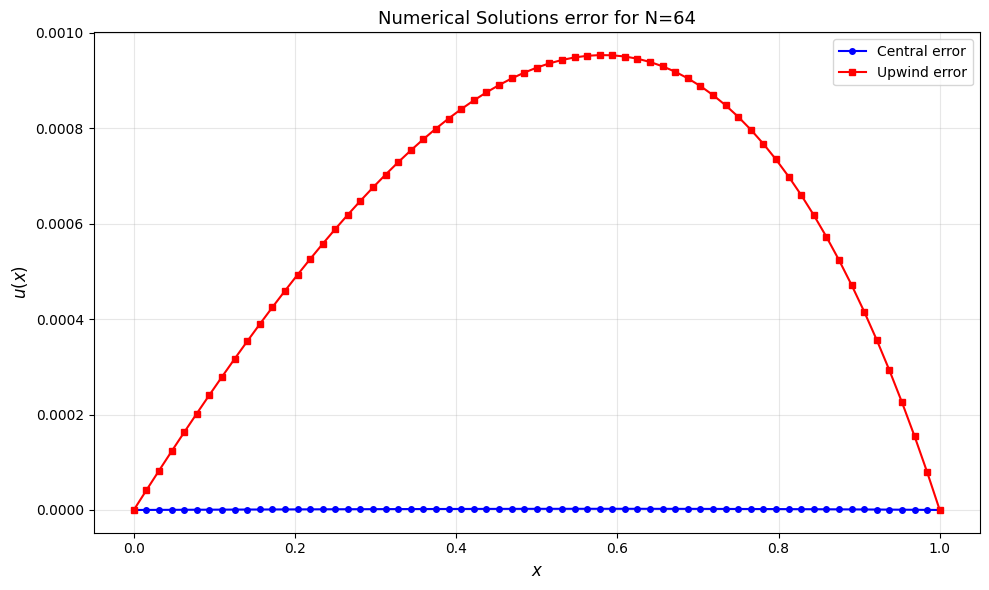

In [4]:
# Finite Difference Method for: u'' + p(x)u' + q(x)u = f(x), u(0)=alpha, u(1)=beta
import numpy as np
import matplotlib.pyplot as plt

# Problem data
alpha = 1
beta = 3
p = lambda x: -1 * np.ones_like(x)  # Convection coefficient (vectorized)
q = lambda x: 0 * np.ones_like(x)   # Reaction coefficient (vectorized)
f = lambda x: -1 * np.ones_like(x)  # Source term (vectorized)
u_exact = lambda x: 1 + x + (np.exp(x) - 1)/(np.exp(1) - 1)  # True solution

# Discretization
N_values = np.array([16, 32, 64, 128, 256, 512, 1024])
errors_cent = np.zeros(len(N_values))
errors_up = np.zeros(len(N_values))

for k, N in enumerate(N_values):
    h = 1/N
    x = np.linspace(0, 1, N+1)
    
    # Interior values (indices 1 to N-1)
    x_interior = x[1:N]
    P = p(x_interior)  # Now returns array
    Q = q(x_interior)  # Now returns array
    F = f(x_interior)  # Now returns array

    # === Central Difference ===
    A_cent = np.zeros((N-1, N-1))
    b_cent = np.zeros(N-1)
    
    for i in range(N-1):
        if i == 0:  # First interior point
            A_cent[i, i] = -2/h**2 + Q[i]
            A_cent[i, i+1] = 1/h**2 + P[i]/(2*h)
            b_cent[i] = F[i] - (1/h**2 - P[i]/(2*h)) * alpha
        elif i == N-2:  # Last interior point
            A_cent[i, i-1] = 1/h**2 - P[i]/(2*h)
            A_cent[i, i] = -2/h**2 + Q[i]
            b_cent[i] = F[i] - (1/h**2 + P[i]/(2*h)) * beta
        else:  # Interior points
            A_cent[i, i-1] = 1/h**2 - P[i]/(2*h)
            A_cent[i, i] = -2/h**2 + Q[i]
            A_cent[i, i+1] = 1/h**2 + P[i]/(2*h)
            b_cent[i] = F[i]
    
    U_cent = np.linalg.solve(A_cent, b_cent)
    U_cent_full = np.concatenate([[alpha], U_cent, [beta]])

    # === Upwind (p < 0 => forward difference) ===
    A_up = np.zeros((N-1, N-1))
    b_up = np.zeros(N-1)
    
    for i in range(N-1):
        if i == 0:  # First interior point
            A_up[i, i] = -2/h**2 - P[i]/h + Q[i]
            A_up[i, i+1] = 1/h**2 + P[i]/h
            b_up[i] = F[i] - (1/h**2) * alpha
        elif i == N-2:  # Last interior point
            A_up[i, i-1] = 1/h**2
            A_up[i, i] = -2/h**2 - P[i]/h + Q[i]
            b_up[i] = F[i] - (1/h**2 + P[i]/h) * beta
        else:  # Interior points
            A_up[i, i-1] = 1/h**2
            A_up[i, i] = -2/h**2 - P[i]/h + Q[i]
            A_up[i, i+1] = 1/h**2 + P[i]/h
            b_up[i] = F[i]
    
    U_up = np.linalg.solve(A_up, b_up)
    U_up_full = np.concatenate([[alpha], U_up, [beta]])

    # Compute errors
    u_true = u_exact(x)
    errors_cent[k] = np.max(np.abs(U_cent_full - u_true))
    errors_up[k] = np.max(np.abs(U_up_full - u_true))

# === Convergence Analysis ===
N_sq = N_values**2
C_cent = errors_cent * N_sq
C_up = errors_up * N_values  # First-order

# Display table
print('\nN\tError (Central)\t\tC = Error*N^2\tError (Upwind)\tC = Error*N')
print('-' * 80)
for k in range(len(N_values)):
    print(f'{N_values[k]}\t{errors_cent[k]:.2e}\t\t{C_cent[k]:.2e}\t\t{errors_up[k]:.2e}\t\t{C_up[k]:.2e}')

# === Plotting ===
plt.figure(figsize=(10, 6))
plt.loglog(N_values, errors_cent, 'bo-', linewidth=2, markersize=8, label='Central Difference (2nd order)')
plt.loglog(N_values, errors_up, 'rs-', linewidth=2, markersize=8, label='Upwind (1st order)')

# Reference slopes
N_ref = np.array([10, 1000])
plt.loglog(N_ref, 1e-3 * (N_ref/10)**(-2), 'b--', alpha=0.5, label='$O(N^{-2})$ reference')
plt.loglog(N_ref, 1e-2 * (N_ref/10)**(-1), 'r--', alpha=0.5, label='$O(N^{-1})$ reference')

plt.xlabel('Number of Grid Points $N$', fontsize=12)
plt.ylabel('Maximum Error', fontsize=12)
plt.title('Convergence Analysis: Central vs Upwind Finite Difference', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

# === Plot Solutions for N=64 ===
N_plot = 64
h = 1/N_plot
x = np.linspace(0, 1, N_plot+1)
x_interior = x[1:N_plot]
P = p(x_interior)
Q = q(x_interior)
F = f(x_interior)

# Central Difference Solution
A_cent = np.zeros((N_plot-1, N_plot-1))
b_cent = np.zeros(N_plot-1)
for i in range(N_plot-1):
    if i == 0:
        A_cent[i, i] = -2/h**2 + Q[i]
        A_cent[i, i+1] = 1/h**2 + P[i]/(2*h)
        b_cent[i] = F[i] - (1/h**2 - P[i]/(2*h)) * alpha
    elif i == N_plot-2:
        A_cent[i, i-1] = 1/h**2 - P[i]/(2*h)
        A_cent[i, i] = -2/h**2 + Q[i]
        b_cent[i] = F[i] - (1/h**2 + P[i]/(2*h)) * beta
    else:
        A_cent[i, i-1] = 1/h**2 - P[i]/(2*h)
        A_cent[i, i] = -2/h**2 + Q[i]
        A_cent[i, i+1] = 1/h**2 + P[i]/(2*h)
        b_cent[i] = F[i]

U_cent = np.linalg.solve(A_cent, b_cent)
U_cent_full = np.concatenate([[alpha], U_cent, [beta]])

# Upwind Solution
A_up = np.zeros((N_plot-1, N_plot-1))
b_up = np.zeros(N_plot-1)
for i in range(N_plot-1):
    if i == 0:
        A_up[i, i] = -2/h**2 - P[i]/h + Q[i]
        A_up[i, i+1] = 1/h**2 + P[i]/h
        b_up[i] = F[i] - (1/h**2) * alpha
    elif i == N_plot-2:
        A_up[i, i-1] = 1/h**2
        A_up[i, i] = -2/h**2 - P[i]/h + Q[i]
        b_up[i] = F[i] - (1/h**2 + P[i]/h) * beta
    else:
        A_up[i, i-1] = 1/h**2
        A_up[i, i] = -2/h**2 - P[i]/h + Q[i]
        A_up[i, i+1] = 1/h**2 + P[i]/h
        b_up[i] = F[i]

U_up = np.linalg.solve(A_up, b_up)
U_up_full = np.concatenate([[alpha], U_up, [beta]])

# Plot solutions
plt.figure(figsize=(10, 6))
#plt.plot(x, u_exact(x), 'k-', linewidth=2, label='Exact Solution')
plt.plot(x, abs(U_cent_full-u_exact(x)), 'bo-', markersize=4, label='Central error')
plt.plot(x, abs(U_up_full-u_exact(x)), 'rs-', markersize=4, label='Upwind error')
plt.xlabel('$x$', fontsize=12)
plt.ylabel('$u(x)$', fontsize=12)
plt.title(f'Numerical Solutions error for N={N_plot}', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Conclusion

- The **central difference** method is second-order accurate but unstable when $ \text{Pe}_i > 1 $. Use only for mildly convection-dominated problems.
- The **upwind** method is first-order accurate but unconditionally stable for $ q(x) \geq 0 $. It avoids oscillations and is preferred for stiff or convection-dominated BVPs.
- Both schemes lead to tridiagonal systems solvable in $ O(N) $ time using the Thomas algorithm.
- Always check the Péclet number and ensure diagonal dominance for reliable results.

### 3.2.2. Extension to Neumann and Robin Boundary Conditions

So far, we have considered Dirichlet boundary conditions $u(a) = \alpha$, $u(b) = \beta$. We now extend the finite difference framework to **Neumann** and **Robin** boundary conditions. The same uniform grid is used:

$$
x_i = a + i h, \quad i = 0, 1, \dots, N, \qquad h = \frac{b-a}{N},
$$

with $u_i \approx u(x_i)$. To maintain second-order accuracy at boundaries involving derivatives, we introduce *ghost points* $u_{-1}$ and $u_{N+1}$, which are eliminated algebraically using the boundary conditions.

#### Neumann Boundary Conditions

Consider

$$
u'(a) = \gamma, \qquad u'(b) = \delta.
$$

Using central differences:

$$
u'(x_0) \approx \frac{u_1 - u_{-1}}{2h} = \gamma 
\;\;\Longrightarrow\;\; u_{-1} = u_1 - 2h\gamma,
$$

$$
u'(x_N) \approx \frac{u_{N+1} - u_{N-1}}{2h} = \delta 
\;\;\Longrightarrow\;\; u_{N+1} = u_{N-1} + 2h\delta.
$$

Substitute these into the discretized differential equation at $i = 0$ and $i = N$, respectively.

- **At $x_0$:**

$$
\frac{u_1 - 2u_0 + u_{-1}}{h^2} + p_0 \frac{u_1 - u_{-1}}{2h} + q_0 u_0 = f_0
$$

$$
\Longrightarrow\;\;
\frac{2(u_1 - u_0)}{h^2} - \frac{2\gamma}{h} + p_0 \gamma + q_0 u_0 = f_0.
$$

Rearranging yields the modified left boundary equation:

$$
\left(-\frac{2}{h^2} + q_0\right) u_0 + \frac{2}{h^2} u_1 
= f_0 + \gamma\left(\frac{2}{h} - p_0\right).
$$

- **At $x_N$:**

$$
\frac{u_{N+1} - 2u_N + u_{N-1}}{h^2} + p_N \frac{u_{N+1} - u_{N-1}}{2h} + q_N u_N = f_N
$$

$$
\Longrightarrow\;\;
\frac{2(u_{N-1} - u_N)}{h^2} + \frac{2\delta}{h} + p_N \delta + q_N u_N = f_N,
$$

which leads to:

$$
\frac{2}{h^2} u_{N-1} + \left(-\frac{2}{h^2} + q_N\right) u_N 
= f_N - \delta\left(\frac{2}{h} + p_N\right).
$$

The unknown vector becomes $\mathbf{U} = [u_0, u_1, \dots, u_N]^T$, and the linear system is $(N+1)\times(N+1)$ tridiagonal.

#### Robin Boundary Conditions

Now consider mixed (Robin) conditions:

$$
u'(a) + \eta\, u(a) = \gamma, \qquad u'(b) + \zeta\, u(b) = \delta,
$$

where $\eta, \zeta \geq 0$ are given constants.

- **Left boundary ($x = a$):**  
  Central approximation gives

$$
\frac{u_1 - u_{-1}}{2h} + \eta u_0 = \gamma 
\;\;\Longrightarrow\;\;
u_{-1} = u_1 + 2h(\eta u_0 - \gamma).
$$

Substituting into the differential equation at $i = 0$ and simplifying yields:

$$
\frac{2}{h^2} u_1 
+ \left(-\frac{2}{h^2} + \frac{2\eta}{h} - \eta p_0 + q_0\right) u_0
= f_0 + \gamma\left(\frac{2}{h} - p_0\right).
$$

- **Right boundary ($x = b$):**  
  Similarly,

$$
\frac{u_{N+1} - u_{N-1}}{2h} + \zeta u_N = \delta 
\;\;\Longrightarrow\;\;
u_{N+1} = u_{N-1} + 2h(\delta - \zeta u_N),
$$

and substitution gives:

$$
\frac{2}{h^2} u_{N-1} 
+ \left(-\frac{2}{h^2} - \frac{2\zeta}{h} - \zeta p_N + q_N\right) u_N
= f_N - \delta\left(\frac{2}{h} + p_N\right).
$$

When $\eta = 0$ (resp. $\zeta = 0$), the Robin conditions reduce to the Neumann case. As $\eta, \zeta \to \infty$ (suitably scaled), the conditions approach Dirichlet type.

#### Matrix Structure and Stability

With Neumann or Robin conditions, the coefficient matrix $A$ remains *banded* (tridiagonal), but the first and last rows are modified. For the central scheme, diagonal dominance at the boundaries requires:

**Left:**
$$
\left| -\frac{2}{h^2} + \frac{2\eta}{h} - \eta p_0 + q_0 \right| \ge \frac{2}{h^2},
$$

**Right:**
$$
\left| -\frac{2}{h^2} - \frac{2\zeta}{h} - \zeta p_N + q_N \right| \ge \frac{2}{h^2}.
$$

These are guaranteed if $q(x) \ge 0$ and $\eta, \zeta > 0$, especially for sufficiently small $h$. In convection-dominated regimes ($|p(x)|$ large), combining Robin/Neumann treatment with the **upwind scheme** in the interior is recommended to preserve monotonicity.

---

#### Summary of Boundary Condition Treatments

| **Type** | **Unknowns** | **Size of System** | **Notes** |
|----------|--------------|-------------------|-----------|
| Dirichlet–Dirichlet | $u_1,\dots,u_{N-1}$ | $(N-1)\times(N-1)$ | BCs move to RHS. |
| Neumann–Neumann | $u_0,\dots,u_N$ | $(N+1)\times(N+1)$ | May be singular if $q\equiv 0$. |
| Dirichlet–Neumann | $u_1,\dots,u_N$ | $N\times N$ | Use Neumann equation at $x_N$. |
| Robin–Robin | $u_0,\dots,u_N$ | $(N+1)\times(N+1)$ | Ensures well-posedness for $\eta,\zeta >0$. |

##### Example with Robin Boundary Condition

**Example:** Consider the linear boundary value problem

$$
u''(x) + \beta\, u'(x) = -1, \qquad 0 < x < 1,
$$

with mixed boundary conditions:

$$
u(0) = 0, \qquad u'(1) + u(1) = 1,
$$

where $\beta \gg 1$ (e.g., $\beta = 50$). This models steady advection-diffusion in which convection strongly dominates diffusion, leading to a thin boundary layer near $x = 0$.

#### Exact Solution

The ODE has constant coefficients. The characteristic equation is $r^2 + \beta r = 0$, yielding roots $r = 0$ and $r = -\beta$. A particular solution is $u_p(x) = -x/\beta$. Thus the general solution is

$$
u(x) = C_1 + C_2 e^{-\beta x} - \frac{x}{\beta}.
$$

Apply $u(0) = 0$: $C_1 + C_2 = 0 \Rightarrow C_1 = -C_2$, so

$$
u(x) = C_2\left(e^{-\beta x} - 1\right) - \frac{x}{\beta}.
$$

Now impose the Robin condition at $x = 1$:

$$
u'(x) = -\beta C_2 e^{-\beta x} - \frac{1}{\beta},
$$

$$
u'(1) + u(1) = \Bigl(-\beta C_2 e^{-\beta} - \frac{1}{\beta}\Bigr)
+ \Bigl(C_2(e^{-\beta} - 1) - \frac{1}{\beta}\Bigr) = 1.
$$

Simplifying:

$$
C_2\bigl(-\beta + 1\bigr)e^{-\beta} - C_2 - \frac{2}{\beta} = 1
\;\;\Longrightarrow\;\;
C_2 = \frac{-1 - \frac{2}{\beta}}{1 + (\beta - 1)e^{-\beta}}.
$$

For large $\beta$, $e^{-\beta} \approx 0$, so $C_2 \approx -1 - 2/\beta \approx -1$. Hence, to leading order:

$$
u(x) \approx \bigl(1 - e^{-\beta x}\bigr) - \frac{x}{\beta}.
$$

A boundary layer of width $O(1/\beta)$ forms near $x = 0$. For $\beta = 100$, the layer width is $\sim 0.01$.

#### Finite Difference Discretization

Let $x_i = i h$, $i = 0,\dots,N$, $h = 1/N$. Unknowns: $\mathbf{U} = [u_1, \dots, u_N]^\top$ ($u_0 = 0$ given).

- **Central difference** at interior points $i = 1,\dots,N-1$:

$$
\frac{u_{i+1} - 2u_i + u_{i-1}}{h^2} + \beta \frac{u_{i+1} - u_{i-1}}{2h} = -1.
$$

Multiply by $h^2$:

$$
\left(1 + \frac{\beta h}{2}\right) u_{i-1} + (-2) u_i + \left(1 - \frac{\beta h}{2}\right) u_{i+1} = -h^2.
$$

This scheme is stable only if $\mathrm{Pe}_i = \frac{\beta h}{2} < 1$; for $\beta = 100$, need $h < 0.02$ ($N > 50$) — barely sufficient, and oscillations appear for $N = 50$.

- **Upwind scheme** ($\beta > 0$, use backward difference for $u'$):

$$
\frac{u_{i+1} - 2u_i + u_{i-1}}{h^2} + \beta \frac{u_i - u_{i-1}}{h} = -1.
$$

Multiply by $h^2$:

$$
(1 - \beta h) u_{i-1} + (-2 + \beta h) u_i + u_{i+1} = -h^2.
$$

Diagonal dominance holds if $\beta h \le 1$, but even for $\beta h > 1$, the matrix remains an M-matrix when $q = 0$ and the Robin condition is used — ensuring monotonicity and stability.

At $i = N$, apply the Robin condition $u'(1) + u(1) = 1$ using a second-order central approximation:

$$
\frac{u_{N+1} - u_{N-1}}{2h} + u_N = 1
\quad\Longrightarrow\quad
u_{N+1} = u_{N-1} + 2h(1 - u_N).
$$

Substitute into the upwind discretization of the ODE at $i = N$:

$$
\frac{u_{N+1} - 2u_N + u_{N-1}}{h^2} + \beta \frac{u_N - u_{N-1}}{h} = -1.
$$

After substitution and simplification, the last equation becomes:

$$
(1 - \beta h) u_{N-1} + \Bigl(-2 + \beta h - \frac{2}{h}\Bigr) u_N = -h^2 - 2.
$$

### 3.2.3. Finite Difference Method for Nonlinear BVPs

Discretizing a nonlinear differential equation generally results in a system of nonlinear algebraic equations. Solving this system numerically yields an approximate solution to the original boundary value problem (BVP). In this section, we present the finite difference method (FDM) for nonlinear BVPs, using Newton's method for solving the resulting nonlinear system.

We focus on a class of quasilinear second-order ODEs, but the method extends to more general forms.

Consider the nonlinear BVP:

$$
-u''(x) + F(u(x)) = f(x), \quad x \in (0,1),
$$

with Dirichlet boundary conditions:

$$
u(0) = 0, \quad u(1) = 0.
$$

We assume $F \in C^1(\mathbb{R})$, ensuring differentiability of the nonlinear term. This includes examples like $F(u) = e^u$, $u^3$, $\sin u$, etc.

#### Finite Difference Discretization

Let:
- $N$: number of interior subintervals
- $h = \frac{1}{N}$: mesh size
- $x_i = i h$, $i = 0, 1, \dots, N$
- $u_i \approx u(x_i)$

Using the central finite difference approximation for the second derivative:

$$
u''(x_i) \approx \frac{u_{i-1} - 2u_i + u_{i+1}}{h^2} + O(h^2),
$$

the discrete form of the BVP at interior points $i = 1, 2, \dots, N-1$ becomes:

$$
-\frac{u_{i-1} - 2u_i + u_{i+1}}{h^2} + F(u_i) = f(x_i).
$$

Since $u_0 = u_N = 0$ (from boundary conditions), we define the vector of unknowns:

$$
\mathbf{u} = [u_1, u_2, \dots, u_{N-1}]^T \in \mathbb{R}^{N-1}.
$$

The system becomes:

$$
\mathbf{G}(\mathbf{u}) = \mathbf{0},
$$

where $\mathbf{G}: \mathbb{R}^{N-1} \to \mathbb{R}^{N-1}$ is defined component-wise by:

$$
G_i(\mathbf{u}) = -\frac{u_{i-1} - 2u_i + u_{i+1}}{h^2} + F(u_i) - f(x_i), \quad i = 1, 2, \dots, N-1,
$$

with $u_0 = 0$, $u_N = 0$.

#### Newton's Iteration Method

To solve $\mathbf{G}(\mathbf{u}) = \mathbf{0}$, we apply Newton's method, which is highly effective for smooth nonlinear systems.

Given an initial guess $\mathbf{u}^{(0)}$, iterate:

$$
\mathbf{u}^{(k+1)} = \mathbf{u}^{(k)} - J(\mathbf{u}^{(k)})^{-1} \mathbf{G}(\mathbf{u}^{(k)}), \quad k = 0, 1, 2, \dots
$$

where $J(\mathbf{u})$ is the Jacobian matrix of $\mathbf{G}$, defined by:

$$
J_{ij} = \frac{\partial G_i}{\partial u_j}.
$$

For our system, $J$ is tridiagonal:

$$
J(\mathbf{u}) =
\begin{bmatrix}
    \frac{2}{h^2} + F'(u_1) & -\frac{1}{h^2} & & \\
    -\frac{1}{h^2} & \frac{2}{h^2} + F'(u_2) & \ddots & \\
    & \ddots & \ddots & -\frac{1}{h^2} \\
    & & -\frac{1}{h^2} & \frac{2}{h^2} + F'(u_{N-1})
\end{bmatrix}
$$

At each Newton step:
- Evaluate residual $\mathbf{G}(\mathbf{u}^{(k)})$
- Compute Jacobian $J(\mathbf{u}^{(k)})$
- Solve linear system: $J(\mathbf{u}^{(k)}) \mathbf{w}^{(k)} = \mathbf{G}(\mathbf{u}^{(k)})$
- Update: $\mathbf{u}^{(k+1)} = \mathbf{u}^{(k)} - \mathbf{w}^{(k)}$
- The iteration stops when $\|\mathbf{G}(\mathbf{u}^{(k)})\| < \mathrm{TOL}$, e.g., $\mathrm{TOL} = 10^{-6}$

> **Remarks on Newton's Method:**
> - The Jacobian must be recomputed at each iteration (unless using a simplified Newton method).
> - It can be computationally expensive for large $N$, but the tridiagonal structure allows efficient $O(N)$ solution via the Thomas algorithm.
> - Newton's method is **locally quadratically convergent**: if $\mathbf{u}^{(0)}$ is sufficiently close to the solution, convergence is very fast.
> - However, it is **not globally convergent**; a poor initial guess may lead to divergence. Use a linear approximation or continuation method if needed.

### Stability and Convergence Analysis

### Consistency

The finite difference scheme is derived from a second-order accurate approximation of the second derivative. Specifically, the local truncation error at node $x_i$ is

$$
\tau_i \;=\; u''(x_i) \;-\; \frac{u(x_{i-1}) - 2u(x_i) + u(x_{i+1})}{h^2}
\;=\; -\frac{h^2}{12}\, u^{(4)}(\xi_i),
\qquad \xi_i \in (x_{i-1}, x_{i+1}).
$$

Hence, if the exact solution satisfies $u \in C^4[0,1]$, then $|\tau_i| \le C h^2$ for some constant $C > 0$ independent of $h$. Since $F(u(x_i))$ and $f(x_i)$ are evaluated exactly (no discretization error in the nonlinear and source terms), the residual of the discrete system satisfies

$$
G_i(\mathbf{u}_{\text{exact}}) = \tau_i = O(h^2), \qquad i=1,\dots,N-1,
$$

where $\mathbf{u}_{\text{exact}} = [u(x_1),\dots,u(x_{N-1})]^T$. Thus, the scheme is second-order consistent.

### Stability

Stability here refers to continuous dependence of the discrete solution on the data, and is guaranteed by the structure of the discrete operator.

The linear part of the scheme corresponds to the discrete Laplacian

$$
(L_h \mathbf{u})_i = -\frac{u_{i-1} - 2u_i + u_{i+1}}{h^2}, \qquad i = 1,\dots,N-1,
$$

with $u_0 = u_N = 0$. The associated matrix $A_h \in \mathbb{R}^{(N-1)\times(N-1)}$ is:
- symmetric
- strictly diagonally dominant
- positive definite
- with eigenvalues $\lambda_k = \frac{4}{h^2} \sin^2\!\left(\frac{k\pi h}{2}\right)$, $k=1,\dots,N-1$
- and smallest eigenvalue satisfying $\lambda_1 \ge \pi^2$ (independent of $h$)

Now suppose $F \in C^1(\mathbb{R})$ and satisfies the monotonicity condition

$$
F'(s) \ge 0 \quad \text{for all } s \in \mathbb{R}.
$$

Then the nonlinear discrete operator $\mathcal{L}_h(\mathbf{u}) = L_h \mathbf{u} + \mathbf{F}(\mathbf{u})$, where $\mathbf{F}(\mathbf{u})_i = F(u_i)$, is:
- **monotone**: $(\mathcal{L}_h(\mathbf{u}) - \mathcal{L}_h(\mathbf{v}))^\top (\mathbf{u} - \mathbf{v}) \ge 0$ for all $\mathbf{u},\mathbf{v}$
- **coercive**: $\mathcal{L}_h(\mathbf{u})^\top \mathbf{u} \to \infty$ as $\|\mathbf{u}\| \to \infty$

These properties ensure:
- existence and uniqueness of the discrete solution $\mathbf{u}_h$
- uniform boundedness: $\|\mathbf{u}_h\|_\infty \le C$, where $C$ depends only on $f$ and $F$, not on $h$
- absence of nonphysical oscillations (maximum principle holds)

Moreover, the Jacobian matrix

$$
J(\mathbf{u}) = A_h + \operatorname{diag}\bigl(F'(u_1),\dots,F'(u_{N-1})\bigr)
$$

inherits the same structural properties: it is symmetric, positive definite, and in fact an M-matrix (all off-diagonal entries $\le 0$, diagonal dominance, and positive diagonal). This guarantees well-conditioned linear solves within Newton's method.

### Convergence of Newton's Method

Newton's method applied to $\mathbf{G}(\mathbf{u}) = \mathbf{0}$ converges *quadratically* under the following standard conditions:
1. $\mathbf{G} \in C^1$ in a neighbourhood of the solution (satisfied since $F \in C^1$)
2. The initial guess $\mathbf{u}^{(0)}$ is sufficiently close to the exact discrete solution $\mathbf{u}_h$
3. The Jacobian $J(\mathbf{u})$ is nonsingular and its inverse is uniformly bounded in that neighbourhood

The monotonicity condition $F'(u) \ge 0$ ensures $J(\mathbf{u}) \succeq A_h$ (in the sense of positive definiteness), and since the smallest eigenvalue of $A_h$ is bounded below by $\pi^2 > 0$, we have

$$
\|J(\mathbf{u})^{-1}\|_2 \le \frac{1}{\pi^2},
$$

uniformly in $h$ and $\mathbf{u}$. Consequently, once the iterate enters the basin of attraction, Newton's method exhibits quadratic convergence:

$$
\|\mathbf{u}^{(k+1)} - \mathbf{u}_h\| \le C \|\mathbf{u}^{(k)} - \mathbf{u}_h\|^2.
$$

#### Overall Convergence of the Finite Difference Method

Combining consistency and stability yields convergence of the numerical solution to the true solution.

> **Theorem (Second-Order Convergence)**
>
> Assume:
> - The exact solution $u \in C^4[0,1]$
> - $F \in C^1(\mathbb{R})$ with $F'(s) \ge 0$ for all $s$
> - $f \in C[0,1]$
>
> Let $\mathbf{u}_h = [u_1, \dots, u_{N-1}]^T$ be the unique solution of the discrete nonlinear system. Then there exists a constant $C > 0$, independent of $h$, such that
>
> $$
> \max_{0 \le i \le N} |u_i - u(x_i)| \;\le\; C h^2.
> $$

> **Proof (Sketch)**
>
> Let $\mathbf{e} = \mathbf{u}_h - \mathbf{u}_{\text{exact}}$ be the error vector. Using a Taylor expansion and the mean value theorem, one obtains
>
> $$
> \mathbf{G}(\mathbf{u}_h) - \mathbf{G}(\mathbf{u}_{\text{exact}}) = J(\boldsymbol{\xi})\, \mathbf{e},
> $$
>
> for some $\boldsymbol{\xi}$ on the line segment between $\mathbf{u}_h$ and $\mathbf{u}_{\text{exact}}$. Since $\mathbf{G}(\mathbf{u}_h) = \mathbf{0}$ and $\|\mathbf{G}(\mathbf{u}_{\text{exact}})\| = O(h^2)$ by consistency, it follows that
>
> $$
> \| \mathbf{e} \| \le \|J(\boldsymbol{\xi})^{-1}\| \cdot \|\mathbf{G}(\mathbf{u}_{\text{exact}})\| \le C h^2,
> $$
>
> where uniform boundedness of $\|J^{-1}\|$ (stability) and the $O(h^2)$ truncation error (consistency) are used. A discrete maximum principle then extends the bound from the interior nodes to the full grid.

**Example:** Consider the nonlinear BVP:

$$
-u''(x) + 1 + e^{u(x)} + u(x)^4 = x + x^2, \quad x \in (0,1),
$$

with $u(0) = u(1) = 0$.

Here, $F(u) = 1 + e^u + u^4$, so $F'(u) = e^u + 4u^3 \geq 0$ for all $u \in \mathbb{R}$.

The residual components:

$$
G_i(\mathbf{u}) = -\frac{u_{i-1} - 2u_i + u_{i+1}}{h^2} + 1 + e^{u_i} + u_i^4 - x_i - x_i^2.
$$

The Jacobian matrix is:

$$
J(\mathbf{u}) =
\begin{bmatrix}
    \frac{2}{h^2} + e^{u_1} + 4u_1^3 & -\frac{1}{h^2} & & \\
    -\frac{1}{h^2} & \frac{2}{h^2} + e^{u_2} + 4u_2^3 & \ddots & \\
    & \ddots & \ddots & -\frac{1}{h^2} \\
    & & -\frac{1}{h^2} & \frac{2}{h^2} + e^{u_{N-1}} + 4u_{N-1}^3
\end{bmatrix}
$$

Using initial guess $\mathbf{u}^{(0)} = \mathbf{0}$ and $\mathrm{TOL} = 10^{-6}$, Newton's method typically converges in 3–5 iterations.

N	Iterations	Residual
----------------------------------------
16	3		3.42e-07
32	3		3.44e-07
64	3		3.44e-07


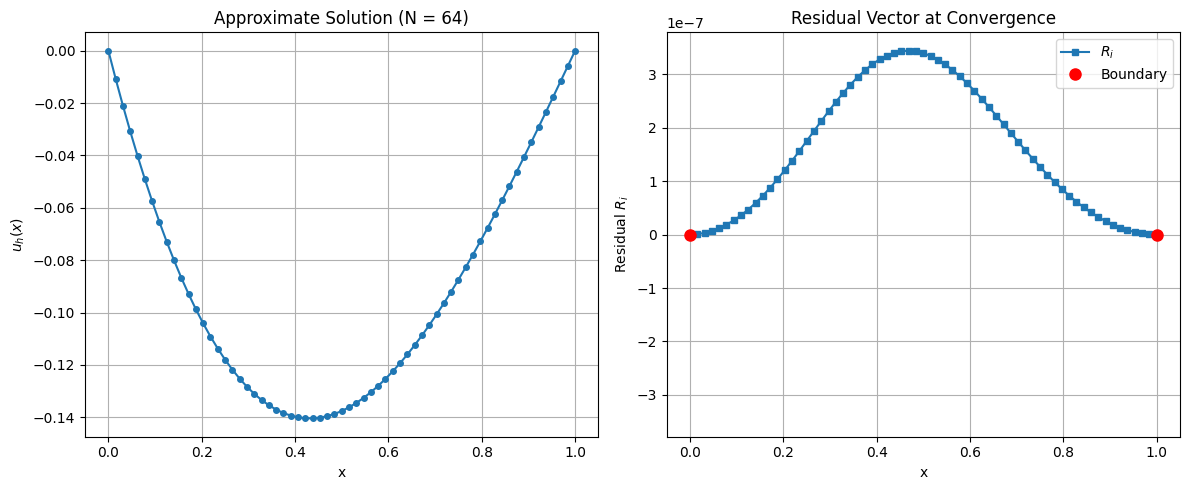

In [5]:
# Nonlinear BVP: -u'' + F(u) = f(x),   u(0) = u(1) = 0
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Problem data
F = lambda u: 1 + np.exp(u) + u**4
dF = lambda u: np.exp(u) + 4*u**3
f_func = lambda x: x + x**2
u0 = 0
u1 = 0
TOL = 1e-6
max_iter = 20

# Grids
N_vals = [16, 32, 64]

print('N\tIterations\tResidual')
print('-' * 40)

# To store finest solution and residual for plotting
U_plot = []
x_plot = []
R_plot = []

for k, N in enumerate(N_vals):
    h = 1/N
    x = np.linspace(0, 1, N+1)
    U = np.zeros(N+1)  # initial guess

    iter_count = 0
    residual = np.inf
    
    while iter_count < max_iter:
        iter_count += 1
        
        # Residual R(U)
        R = np.zeros(N+1)
        R[0] = U[0] - u0
        R[N] = U[N] - u1
        
        for i in range(1, N):
            neg_u2 = (-U[i-1] + 2*U[i] - U[i+1]) / h**2  # -u''
            R[i] = neg_u2 + F(U[i]) - f_func(x[i])
        
        residual = np.linalg.norm(R[1:N], ord=np.inf)
        
        if residual < TOL:
            break
        
        # Jacobian (sparse matrix)
        J = lil_matrix((N+1, N+1))
        J[0, 0] = 1
        J[N, N] = 1
        
        for i in range(1, N):
            J[i, i-1] = -1/h**2
            J[i, i] = 2/h**2 + dF(U[i])
            J[i, i+1] = -1/h**2
        
        # Newton update
        J_csr = J.tocsr()
        dU = spsolve(J_csr, R)
        U = U - dU
    
    print(f'{N}\t{iter_count}\t\t{residual:.2e}')
    
    # Save finest grid solution and residual for plotting
    if N == max(N_vals):
        U_plot = U.copy()
        x_plot = x.copy()
        R_plot = R.copy()

# ------------------ Plotting ------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Approximate solution
ax1.plot(x_plot, U_plot, '-o', markersize=4, linewidth=1.5)
ax1.set_xlabel('x')
ax1.set_ylabel('$u_h(x)$')
ax1.set_title(f'Approximate Solution (N = {max(N_vals)})')
ax1.grid(True)

# Plot 2: Residual R(x)
ax2.plot(x_plot, R_plot, '-s', markersize=4, linewidth=1.5, label='$R_i$')
ax2.set_xlabel('x')
ax2.set_ylabel('Residual $R_i$')
ax2.set_title('Residual Vector at Convergence')
ax2.grid(True)
ax2.set_ylim([-max(np.abs(R_plot))*1.1, max(np.abs(R_plot))*1.1])

# Highlight interior vs boundaries
ax2.plot(x_plot[[0, -1]], R_plot[[0, -1]], 'ro', markersize=8, label='Boundary')
ax2.legend()

plt.tight_layout()
plt.show()

#### General Nonlinear BVP: $u'' = f(x,u,u')$

Consider the second-order nonlinear boundary value problem

$$
u''(x) = f\bigl(x, u(x), u'(x)\bigr), \qquad 0 < x < 1,
$$

subject to Dirichlet boundary conditions

$$
u(0) = u_0, \qquad u(1) = u_1,
$$

where $f: [0,1] \times \mathbb{R} \times \mathbb{R} \to \mathbb{R}$ is a given smooth function.

##### Finite Difference Discretization

Introduce a uniform grid

$$
x_i = i h, \qquad i = 0, 1, \dots, N+1, \qquad h = \frac{1}{N+1},
$$

so that $x_0 = 0$, $x_{N+1} = 1$. Let $u_i \approx u(x_i)$ denote the numerical approximation, with $u_0 = u_0$ and $u_{N+1} = u_1$ prescribed.

We approximate derivatives using second-order central differences:

$$
u''(x_i) \approx \frac{u_{i+1} - 2u_i + u_{i-1}}{h^2},
$$

$$
u'(x_i) \approx \frac{u_{i+1} - u_{i-1}}{2h}.
$$

Substituting into the BVP yields, for each interior node $i = 1, \dots, N$, the nonlinear algebraic equation:

$$
G_i(\mathbf{u}) = 
\frac{u_{i+1} - 2u_i + u_{i-1}}{h^2}
- f\!\left(
    x_i,\;
    u_i,\;
    \frac{u_{i+1} - u_{i-1}}{2h}
\right)
= 0,
$$

where $\mathbf{u} = [u_1, u_2, \dots, u_N]^\top \in \mathbb{R}^N$ is the vector of unknowns.

Thus, the discrete problem is to find $\mathbf{u} \in \mathbb{R}^N$ such that

$$
\mathbf{G}(\mathbf{u}) = \mathbf{0}, \qquad \mathbf{G} = [G_1, \dots, G_N]^\top.
$$

##### Newton's Method

Since $\mathbf{G}$ is nonlinear (in general), we solve $\mathbf{G}(\mathbf{u}) = \mathbf{0}$ using Newton's method:

Given an initial guess $\mathbf{u}^{(0)}$, iterate for $k = 0, 1, 2, \dots$:

$$
\mathbf{u}^{(k+1)} = \mathbf{u}^{(k)} - \bigl[J(\mathbf{u}^{(k)})\bigr]^{-1} \mathbf{G}(\mathbf{u}^{(k)}),
$$

where $J(\mathbf{u}) = \partial \mathbf{G}/\partial \mathbf{u} \in \mathbb{R}^{N \times N}$ is the Jacobian matrix.

The entries of $J$ are obtained by differentiating:

$$
\frac{\partial G_i}{\partial u_{i-1}} 
= \frac{1}{h^2} + \frac{1}{2h}\, f_{u'}\!\left(x_i, u_i, \frac{u_{i+1} - u_{i-1}}{2h}\right),
$$

$$
\frac{\partial G_i}{\partial u_i} 
= -\frac{2}{h^2} - f_u\!\left(x_i, u_i, \frac{u_{i+1} - u_{i-1}}{2h}\right),
$$

$$
\frac{\partial G_i}{\partial u_{i+1}} 
= \frac{1}{h^2} - \frac{1}{2h}\, f_{u'}\!\left(x_i, u_i, \frac{u_{i+1} - u_{i-1}}{2h}\right),
$$

where $f_u = \partial f/\partial u$ and $f_{u'} = \partial f/\partial u'$ are evaluated at the current iterate. All other partials are zero, so $J(\mathbf{u})$ is **tridiagonal**.

At each Newton step:
1. Evaluate residual $\mathbf{G}(\mathbf{u}^{(k)})$
2. Assemble Jacobian $J(\mathbf{u}^{(k)})$
3. Solve the linear system $J(\mathbf{u}^{(k)}) \mathbf{w}^{(k)} = \mathbf{G}(\mathbf{u}^{(k)})$ (e.g., via Thomas algorithm, $O(N)$)
4. Update $\mathbf{u}^{(k+1)} = \mathbf{u}^{(k)} - \mathbf{w}^{(k)}$

The iteration terminates when $\|\mathbf{G}(\mathbf{u}^{(k)})\|_\infty < \text{TOL}$ (e.g., $\text{TOL} = 10^{-8}$).

### Consistency

Assume the exact solution $u \in C^4[0,1]$. The truncation error of the second derivative approximation is

$$
u''(x_i) - \frac{u(x_{i+1}) - 2u(x_i) + u(x_{i-1})}{h^2} = -\frac{h^2}{12}u^{(4)}(\xi_i),
$$

and for the first derivative,

$$
u'(x_i) - \frac{u(x_{i+1}) - u(x_{i-1})}{2h} = -\frac{h^2}{6}u^{(3)}(\eta_i),
$$

for some $\xi_i, \eta_i \in (x_{i-1}, x_{i+1})$.

Using a Taylor expansion of $f$ and the smoothness of $f$, one finds the local residual at the exact solution satisfies

$$
G_i(\mathbf{u}_{\text{exact}}) = O(h^2), \qquad i = 1,\dots,N,
$$

i.e., the scheme is second-order consistent.

### Stability

Stability of the nonlinear scheme hinges on the properties of $f$. A standard sufficient condition is the **uniform monotonicity** of the continuous operator, which translates to assumptions on the partial derivatives of $f$. Suppose there exist constants $\alpha > 0$, $\beta \ge 0$ such that for all $(x, u, p)$,

$$
f_u(x, u, p) \ge \alpha > 0, \qquad |f_{u'}(x, u, p)| \le \beta.
$$

Under this condition, the Jacobian $J(\mathbf{u})$ is strictly diagonally dominant for sufficiently small $h$:

$$
\left| \frac{\partial G_i}{\partial u_i} \right|
= \left| \frac{2}{h^2} + f_u \right|
\ge \frac{2}{h^2} + \alpha,
$$

while

$$
\left| \frac{\partial G_i}{\partial u_{i-1}} \right| + \left| \frac{\partial G_i}{\partial u_{i+1}} \right|
\le \frac{2}{h^2} + \frac{\beta}{h}.
$$

Thus, diagonal dominance holds provided

$$
\frac{2}{h^2} + \alpha > \frac{2}{h^2} + \frac{\beta}{h}
\quad \Longleftrightarrow \quad
h < \frac{\alpha}{\beta} \quad (\text{if } \beta > 0).
$$

In particular:
- If $f_{u'} \equiv 0$ (no dependence on $u'$), then $J$ is diagonally dominant for all $h > 0$
- If $f_{u'} \ne 0$, diagonal dominance (and hence invertibility) is guaranteed for sufficiently fine meshes

Moreover, the diagonal entries of $J$ are positive and off-diagonal entries are bounded, ensuring that $J$ is an **M-matrix** when $h$ is small enough—hence $J^{-1} \ge 0$ elementwise and $\|J^{-1}\|_\infty$ is uniformly bounded. This guarantees well-posed linear solves and prevents spurious oscillations.

### Convergence of the Discrete Solution

We now establish convergence of the numerical solution $u_i$ to the exact solution $u(x_i)$.

> **Theorem (Convergence)**
>
> Assume:
> 1. $u \in C^4[0,1]$ is the unique solution of the BVP
> 2. $f \in C^2([0,1] \times \mathbb{R} \times \mathbb{R})$
> 3. The monotonicity condition holds
> 4. The Newton iteration converges to a solution $\mathbf{u}_h$ of $\mathbf{G}(\mathbf{u}) = \mathbf{0}$
>
> Then there exists $h_0 > 0$ and a constant $C > 0$, independent of $h$, such that for all $0 < h \le h_0$,
>
> $$
 \max_{0 \le i \le N+1} |u_i - u(x_i)| \le C h^2.
$$

> **Proof**
>
> Let $\mathbf{e} = \mathbf{u}_h - \mathbf{u}_{\text{exact}}$ be the error vector (restricted to interior nodes). By the mean value theorem applied componentwise to $\mathbf{G}$, there exists $\boldsymbol{\xi}$ on the segment between $\mathbf{u}_h$ and $\mathbf{u}_{\text{exact}}$ such that
>
> $$
\mathbf{0} - \mathbf{G}(\mathbf{u}_{\text{exact}}) = \mathbf{G}(\mathbf{u}_h) - \mathbf{G}(\mathbf{u}_{\text{exact}})
= J(\boldsymbol{\xi})\, \mathbf{e}.
 $$
>
> Hence,
>
> $$
 \mathbf{e} = - J(\boldsymbol{\xi})^{-1} \mathbf{G}(\mathbf{u}_{\text{exact}}).
 $$
>
> By consistency, $\|\mathbf{G}(\mathbf{u}_{\text{exact}})\|_\infty = O(h^2)$. By stability (M-matrix property), $\|J(\boldsymbol{\xi})^{-1}\|_\infty \le M$ for some $M > 0$ independent of $h$. Therefore,
>$$
\|\mathbf{e}\|_\infty \le M \cdot O(h^2) = O(h^2).
 $$
>
> Since $u_0$ and $u_{N+1}$ are exact by construction, the full-grid error satisfies
> $$
 \max_{0 \le i \le N+1} |u_i - u(x_i)| = O(h^2).
 $$

##### Convergence of Newton's Iteration

Newton's method converges *quadratically* if the initial guess is sufficiently close to the discrete solution $\mathbf{u}_h$, and if $J(\mathbf{u})$ is Lipschitz continuous and uniformly nonsingular in a neighbourhood of $\mathbf{u}_h$. The latter holds under the monotonicity condition, since

$$
\lambda_{\min}\bigl(J(\mathbf{u})\bigr) \ge \frac{2}{h^2} + \alpha - \frac{\beta}{h} \ge c > 0
$$

for $h < \alpha/\beta$ (or all $h$ if $\beta = 0$). Hence, once $\|\mathbf{u}^{(0)} - \mathbf{u}_h\|$ is small enough,

$$
\|\mathbf{u}^{(k+1)} - \mathbf{u}_h\| \le C \|\mathbf{u}^{(k)} - \mathbf{u}_h\|^2.
$$

In practice, a good initial guess can be obtained from:
- The solution of the linearized problem ($f$ linearized about $u = \text{linear interpolant}$)
- Continuation in a parameter (e.g., scale $f \to \lambda f$ with $\lambda \in [0,1]$)
- Or simply $\mathbf{u}^{(0)} = $ linear interpolation between $u_0$ and $u_1$ (often sufficient for moderate nonlinearity)

Thus, under reasonable smoothness and monotonicity assumptions, the central-difference discretization of the general nonlinear BVP is second-order accurate, stable, and efficiently solvable via Newton's method with quadratic convergence.

#### Example (Lab Work)

Using finite difference method, approximate the solution of 

$$
y'' = \frac{32 + 2x^3 - yy'}{8}, \quad \text{for } 1 < x < 3
$$

with boundary conditions 

$$
y(1) = 17, \qquad y(3) = \frac{43}{3}.
$$

Use $N = 10, 20, 40, 80$ grid points. Take tolerance $\text{tol} = 10^{-5}$ and maximum number of iterations $m = 10$. 

**Exact solution:** $y(x) = x^2 + \frac{16}{x}$

#### Solution

Let $N \in \mathbb{N}$ be the number of subintervals and define the uniform step size

$$
h = \frac{3 - 1}{N} = \frac{2}{N}.
$$

The grid points are given by

$$
x_i = 1 + i h, \qquad i = 0, 1, \dots, N.
$$

Denote the numerical approximation to $y(x_i)$ by $u_i$. The boundary values are fixed:

$$
u_0 = 17, \qquad u_N = \frac{43}{3}.
$$

Using second-order central differences:

$$
u''(x_i) \approx \frac{u_{i-1} - 2u_i + u_{i+1}}{h^2},
$$

$$
u'(x_i) \approx \frac{u_{i+1} - u_{i-1}}{2h},
$$

the differential equation at interior node $x_i$ ($i = 1, 2, \dots, N-1$) becomes

$$
\frac{u_{i-1} - 2u_i + u_{i+1}}{h^2}
= \frac{1}{8}\left( 32 + 2x_i^3 - u_i \cdot \frac{u_{i+1} - u_{i-1}}{2h} \right).
$$

Multiplying both sides by $h^2$ and rearranging yields the nonlinear finite difference equation:

$$
\left( 1 + \frac{h\,u_i}{16} \right) u_{i-1}
\; - \; 2u_i
\; + \; \left( 1 - \frac{h\,u_i}{16} \right) u_{i+1}
\; = \; \frac{h^2}{8} \left( 32 + 2x_i^3 \right),
\qquad (i = 1,\dots,N-1).
$$

#### Nonlinear System and Solution Strategy

Define the residual vector $\mathbf{F}(\mathbf{u}) = [F_1, F_2, \dots, F_{N-1}]^\top$ with components

$$
F_i(\mathbf{u}) = 
\left( 1 + \frac{h\,u_i}{16} \right) u_{i-1}
- 2u_i
+ \left( 1 - \frac{h\,u_i}{16} \right) u_{i+1}
- \frac{h^2}{8} \left( 32 + 2x_i^3 \right),
$$

where $u_0 = 17$ and $u_N = 43/3$ are imposed.

The system $\mathbf{F}(\mathbf{u}) = \mathbf{0}$ is solved using Newton's method:

1. **Choose an initial guess** $\mathbf{u}^{(0)}$ (e.g., linear interpolation or exact solution)
2. **For** $k = 0, 1, \dots, m-1$ (with $m = 10$):
   - Assemble the Jacobian matrix $J^{(k)} = \frac{\partial \mathbf{F}}{\partial \mathbf{u}}\big|_{\mathbf{u}^{(k)}}$, which is tridiagonal. For $2 \le i \le N-2$:
     
     $$
     \frac{\partial F_i}{\partial u_{i-1}} = 1 + \frac{h\,u_i^{(k)}}{16},
     $$
     
     $$
     \frac{\partial F_i}{\partial u_i} = \frac{h}{16}\big(u_{i-1}^{(k)} - u_{i+1}^{(k)}\big) - 2,
     $$
     
     $$
     \frac{\partial F_i}{\partial u_{i+1}} = 1 - \frac{h\,u_i^{(k)}}{16}.
     $$
     
   - Boundary-adjacent rows ($i=1$ and $i=N-1$) incorporate the known $u_0$ and $u_N$ analogously
   - Solve the linear system $J^{(k)} \Delta \mathbf{u}^{(k)} = -\mathbf{F}(\mathbf{u}^{(k)})$
   - Update: $\mathbf{u}^{(k+1)} = \mathbf{u}^{(k)} + \Delta \mathbf{u}^{(k)}$
   - Stop if $\|\Delta \mathbf{u}^{(k)}\|_\infty < \text{tol} = 10^{-5}$

In [6]:
# Lab Work: Nonlinear BVP y'' = (32 + 2x^3 - y*y')/8,  y(1)=17, y(3)=43/3   # Exact solution: y(x) = x^2 + 16/x

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Problem data
a, b = 1.0, 3.0                      # domain [a,b]
ya, yb = 17.0, 43.0/3.0              # Dirichlet BCs
f = lambda x, y, yp: (32 + 2*x**3 - y*yp)/8
y_exact = lambda x: x**2 + 16/x

# Grid refinements
Ns = [10, 20, 40, 80]
tol = 1e-5
max_iter = 10

errors_inf = np.zeros(len(Ns))
errors_l2 = np.zeros(len(Ns))

print('=' * 80)
print("Nonlinear BVP: y'' = (32 + 2x^3 - y*y')/8,  y(1)=17, y(3)=43/3")
print('Exact: y(x) = x^2 + 16/x')
print('=' * 80)
print(f'{"N":>4} | {"h":>6} | {"||e||_inf":>11} | {"||e||_l2":>10} | {"Newton iters":>12}')
print('-' * 80)

# Store results for plotting (use last N)
final_results = {}

for k, N in enumerate(Ns):
    h = (b - a) / (N + 1)                # uniform step
    x = np.linspace(a, b, N + 2)         # x_0=1, x_{N+1}=3
    
    # Initial guess: linear interpolation (interior points only)
    y_full = np.linspace(ya, yb, N + 2)
    y = y_full[1:-1].copy()              # interior only: y_1 ... y_N
    
    # Newton iteration
    for iteration in range(1, max_iter + 1):
        G = np.zeros(N)
        J = lil_matrix((N, N))           # sparse tridiagonal
        
        for i in range(N):               # i = 0, 1, ..., N-1 (Python indexing)
            xi = x[i + 1]                # x_1, x_2, ..., x_N
            yi = y[i]
            
            # Neighboring values (include BCs)
            if i == 0:
                y_im1 = ya               # left boundary
            else:
                y_im1 = y[i - 1]
            
            if i == N - 1:
                y_ip1 = yb               # right boundary
            else:
                y_ip1 = y[i + 1]
            
            # Central differences
            ypp = (y_ip1 - 2*yi + y_im1) / h**2
            yp = (y_ip1 - y_im1) / (2*h)
            
            # Residual: G_i = y''_i - f(x_i, y_i, y'_i)
            G[i] = ypp - f(xi, yi, yp)
            
            # Partial derivatives of f
            fy = -yp / 8                  # ∂f/∂y = -y'/8
            fyp = -yi / 8                 # ∂f/∂y' = -y/8
            
            # Jacobian: dG_i / dy_j
            J[i, i] = -2/h**2 - fy        # diagonal
            
            if i > 0:
                J[i, i-1] = 1/h**2 + (1/(2*h)) * fyp   # sub-diagonal
            
            if i < N - 1:
                J[i, i+1] = 1/h**2 - (1/(2*h)) * fyp   # super-diagonal
        
        # Solve linear system: J * delta = -G
        J_csr = J.tocsr()
        delta = spsolve(J_csr, -G)
        y = y + delta
        
        # Check convergence
        if np.linalg.norm(G, ord=np.inf) < tol:
            break
    
    # Assemble full solution (with boundaries)
    y_num = np.concatenate([[ya], y, [yb]])
    y_ex = y_exact(x)
    e = y_num - y_ex
    
    err_inf = np.linalg.norm(e, ord=np.inf)
    err_l2 = np.sqrt(h) * np.linalg.norm(e, ord=2)
    
    errors_inf[k] = err_inf
    errors_l2[k] = err_l2
    
    print(f'{N:4d} | {h:6.4f} | {err_inf:11.3e} | {err_l2:10.3e} | {iteration:12d}')
    
    # Store final results for plotting
    if N == Ns[-1]:
        final_results = {'x': x, 'y_num': y_num, 'y_ex': y_ex, 'e': e, 'N': N}

print('=' * 80)

# Convergence rates
print('\nConvergence (||e||_∞):')
print(f'{"N":>6} | {"Order":>7}')
print('-' * 15)
for k in range(1, len(Ns)):
    order = np.log(errors_inf[k-1] / errors_inf[k]) / np.log(2)
    print(f'{Ns[k]:6d} | {order:7.2f}')

Nonlinear BVP: y'' = (32 + 2x^3 - y*y')/8,  y(1)=17, y(3)=43/3
Exact: y(x) = x^2 + 16/x
   N |      h |   ||e||_inf |   ||e||_l2 | Newton iters
--------------------------------------------------------------------------------
  10 | 0.1818 |   8.152e-03 |  8.040e-03 |            4
  20 | 0.0952 |   2.227e-03 |  2.188e-03 |            4
  40 | 0.0488 |   5.840e-04 |  5.728e-04 |            4
  80 | 0.0247 |   1.496e-04 |  1.467e-04 |            4

Convergence (||e||_∞):
     N |   Order
---------------
    20 |    1.87
    40 |    1.93
    80 |    1.96


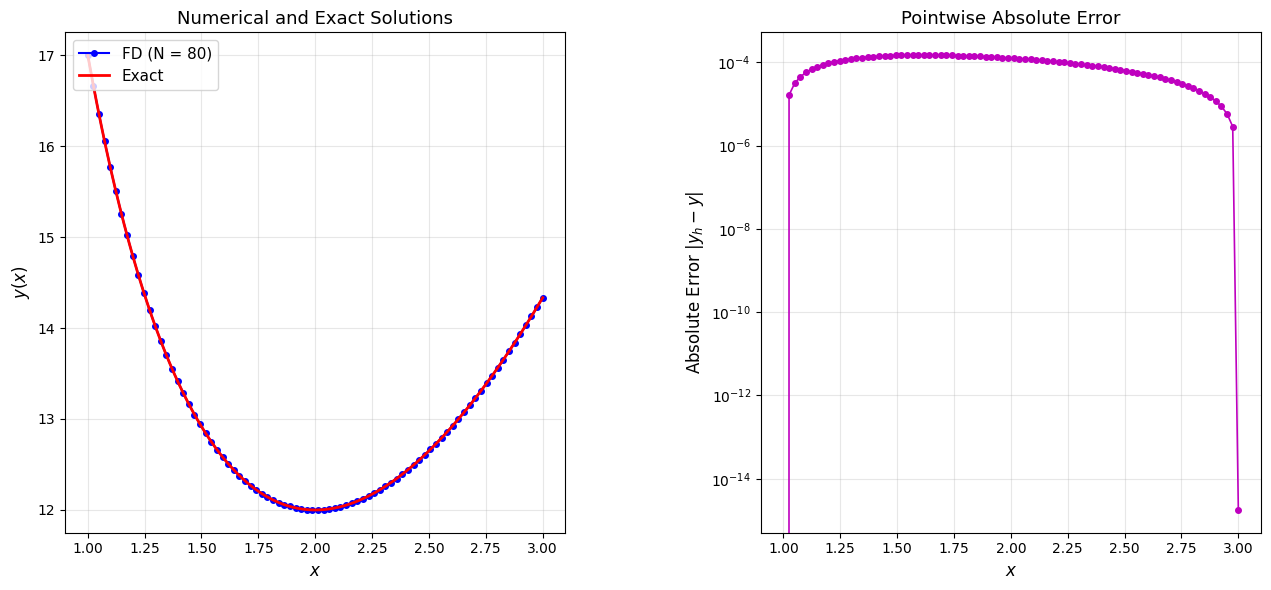

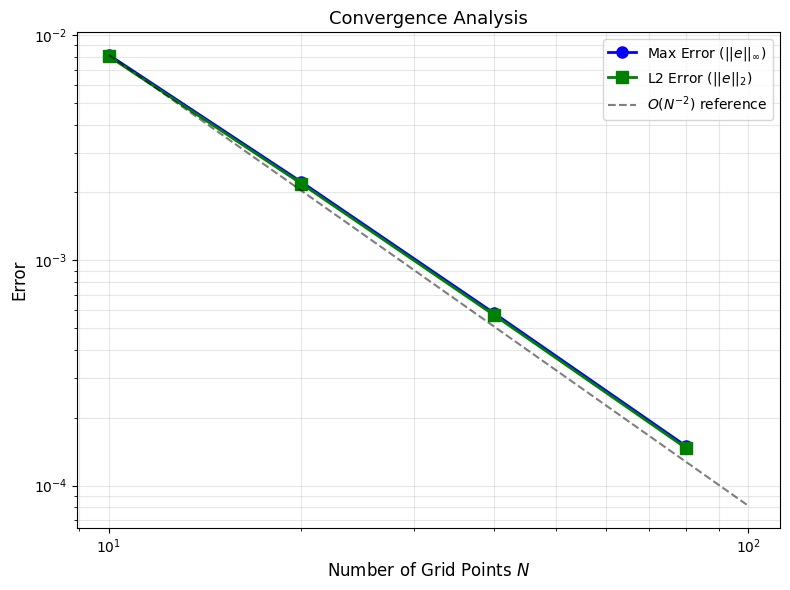

In [7]:
# ==================== Plotting ====================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Fine grid for exact solution (smooth curve)
x_fine = np.linspace(a, b, 1000)
y_ex_fine = y_exact(x_fine)

# Left subplot: solution
ax1.plot(final_results['x'], final_results['y_num'], 'bo-', 
         markerfacecolor='b', markersize=4, label=f"FD (N = {final_results['N']})")
ax1.plot(x_fine, y_ex_fine, 'r-', linewidth=2, label='Exact')
ax1.set_xlabel('$x$', fontsize=12)
ax1.set_ylabel('$y(x)$', fontsize=12)
ax1.set_title('Numerical and Exact Solutions', fontsize=13)
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_box_aspect(1)

# Right subplot: absolute error
ax2.semilogy(final_results['x'], np.abs(final_results['e']), 'm.-', 
             markersize=8, linewidth=1.2)
ax2.set_xlabel('$x$', fontsize=12)
ax2.set_ylabel('Absolute Error $|y_h - y|$', fontsize=12)
ax2.set_title('Pointwise Absolute Error', fontsize=13)
ax2.grid(True, alpha=0.3, which='both')
ax2.set_box_aspect(1)

plt.tight_layout()
plt.show()

# Convergence plot
fig2, ax = plt.subplots(figsize=(8, 6))
ax.loglog(Ns, errors_inf, 'bo-', linewidth=2, markersize=8, label='Max Error ($||e||_\\infty$)')
ax.loglog(Ns, errors_l2, 'gs-', linewidth=2, markersize=8, label='L2 Error ($||e||_2$)')

# Reference slope for 2nd order
N_ref = np.array([10, 100])
ax.loglog(N_ref, errors_inf[0] * (N_ref/Ns[0])**(-2), 'k--', alpha=0.5, label='$O(N^{-2})$ reference')

ax.set_xlabel('Number of Grid Points $N$', fontsize=12)
ax.set_ylabel('Error', fontsize=12)
ax.set_title('Convergence Analysis', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Display sample solution values for finest grid
print('\n' + '=' * 80)
print(f'Solution Values for N = {final_results["N"]} (Finest Grid)')
print('=' * 80)
print(f'\n{"x":>10} | {"Numerical":>12} | {"Exact":>12} | {"Error":>12}')
print('-' * 80)
step = max(1, final_results['N'] // 10)
for i in range(0, len(final_results['x']), step):
    print(f'{final_results["x"][i]:10.4f} | {final_results["y_num"][i]:12.6f} | '
          f'{final_results["y_ex"][i]:12.6f} | {np.abs(final_results["e"][i]):12.2e}')


Solution Values for N = 80 (Finest Grid)

         x |    Numerical |        Exact |        Error
--------------------------------------------------------------------------------
    1.0000 |    17.000000 |    17.000000 |     0.00e+00
    1.1975 |    14.794809 |    14.794905 |     9.60e-05
    1.3951 |    13.415086 |    13.415224 |     1.38e-04
    1.5926 |    12.582713 |    12.582863 |     1.50e-04
    1.7901 |    12.142329 |    12.142473 |     1.44e-04
    1.9877 |    12.000331 |    12.000459 |     1.28e-04
    2.1852 |    12.096963 |    12.097068 |     1.06e-04
    2.3827 |    12.392282 |    12.392362 |     8.00e-05
    2.5802 |    12.858578 |    12.858631 |     5.33e-05
    2.7778 |    13.476022 |    13.476049 |     2.72e-05
    2.9753 |    14.230052 |    14.230055 |     2.87e-06
